# FinBERT 每日每只股票的情感分数 FNSPID数据集

In [1]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import os

In [ ]:

# import pandas as pd
# import torch
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# from tqdm import tqdm
# import os
# # def extract_and_predict():
# """
# 从测试集抽取1000条有效样本并进行FinBERT预测
# """

# print("="*60)
# print("Step 1: 读取测试集并抽取样本")
# print("="*60)

# # 读取测试集（只读取需要的列以节省内存）
# usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']


# # ============测试1000条数据============
# # print("正在读取测试集...")
# # df = pd.read_csv("02_A_finbert/FNSPID_data/test.csv", usecols=usecols)
# # print(f"总样本数: {len(df):,}")

# # # 过滤出有标题的行（所有行都有，但确保安全）
# # valid_df = df[df['Article_title'].notna()].copy()
# # print(f"有效样本数: {len(valid_df):,}")

# # # 随机抽取1000条
# # sample_size = 1000
# # sampled_df = valid_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
# # print(f"抽取样本数: {len(sampled_df)}")

# # # 保存抽取的样本
# # sample_path = "02_A_finbert/FNSPID_data/test_sample_1000.csv"
# # sampled_df.to_csv(sample_path, index=False)
# # print(f"样本已保存到: {sample_path}")



# # ============使用全部数据============
# print("正在读取训练集...")
# df = pd.read_csv("FNSPID_data/All_external.csv", usecols=usecols)
# print(f"总样本数: {len(df):,}")

# # 过滤出有标题的行（所有行都有，但确保安全）
# valid_df = df[df['Article_title'].notna()].copy()
# print(f"有效样本数: {len(valid_df):,}")

# sampled_df = valid_df


Step 1: 读取测试集并抽取样本
正在读取训练集...


C:\Users\Xinny\AppData\Local\Temp\ipykernel_10548\377556424.py:42: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("02_A_finbert/FNSPID_data/All_external.csv", usecols=usecols)


总样本数: 13,057,514
有效样本数: 13,057,513


### Step 1: 读取全部数据并筛选2009年至今


In [4]:
print("="*60)
print("Step 1: 读取全部数据并筛选2009年至今")
print("="*60)

# 读取全部数据（只读取需要的列以节省内存）
usecols = ['Date', 'Stock_symbol', 'Article_title', 'Url', 'Publisher']

# ============使用全部数据 All_external.csv ============
print("正在读取全部数据...")
df = pd.read_csv("FNSPID_data/All_external.csv", usecols=usecols)
print(f"总样本数: {len(df):,}")

# 过滤出有标题的行
valid_df = df[df['Article_title'].notna()].copy()
print(f"有效样本数: {len(valid_df):,}")

# 转换日期格式（处理带时区的格式）
print("正在转换日期格式...")
# 处理可能的时间戳格式: 1914-09-16 00:00:00+00:00
valid_df['Date'] = pd.to_datetime(valid_df['Date'], utc=True)
# 移除时区信息，统一为无时区的datetime
valid_df['Date'] = valid_df['Date'].dt.tz_localize(None)
print(f"日期范围: {valid_df['Date'].min()} 到 {valid_df['Date'].max()}")

# # 筛选2009年至今
# start_date = '2009-04-01'
# # end_date = pd.Timestamp.now()  # 现在的日期
# # end_date = '2020-06-11'  # 或者指定为 '2020-06-11'


# # 方式1: 筛选到2020-06-11（数据截止日期）
# end_date_data = '2020-06-11'
# filtered_df = valid_df[(valid_df['Date'] >= start_date) & (valid_df['Date'] <= end_date_data)].copy()

# print(f"\n筛选条件: {start_date} 到 {end_date_data}")
# print(f"筛选后样本数: {len(filtered_df):,}")

# # 检查实际日期范围
# # print(f"实际日期范围: {filtered_df['Date'].min()} 到 {filtered_df['Date'].max()}")

# # 按年份统计样本数量
# print("\n按年份统计样本数量:")
# filtered_df['Year'] = filtered_df['Date'].dt.year
# year_counts = filtered_df['Year'].value_counts().sort_index()
# for year, count in year_counts.items():
#     print(f"  {year}: {count:,} 条")

# # 删除临时年份列
# filtered_df = filtered_df.drop('Year', axis=1)

# # 保存筛选后的数据
# os.makedirs("FNSPID_data", exist_ok=True)
# output_path = "FNSPID_data/All_external_2009_2020.csv"
# filtered_df.to_csv(output_path, index=False)
# print(f"\n✅ 筛选后的数据已保存到: {output_path}")
# print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

# sampled_df = filtered_df

Step 1: 读取全部数据并筛选2009年至今
正在读取全部数据...


C:\Users\Xinny\AppData\Local\Temp\ipykernel_23328\454832644.py:10: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("FNSPID_data/All_external.csv", usecols=usecols)


总样本数: 13,057,514
有效样本数: 13,057,513
正在转换日期格式...
日期范围: 1914-09-16 00:00:00 到 2020-06-11 13:12:35

筛选条件: 2009-04-01 到 2020-06-11
筛选后样本数: 11,130,950

按年份统计样本数量:
  2009: 731,050 条
  2010: 1,200,802 条
  2011: 1,571,048 条
  2012: 1,569,853 条
  2013: 1,192,744 条
  2014: 1,166,278 条
  2015: 1,364,956 条
  2016: 686,338 条
  2017: 344,705 条
  2018: 523,476 条
  2019: 578,683 条
  2020: 201,017 条

✅ 筛选后的数据已保存到: FNSPID_data/All_external_2009_2020.csv
   文件大小: 1951.58 MB


In [ ]:

# 筛选2009年至今
start_date = '2009-04-01'
# end_date = pd.Timestamp.now()  # 现在的日期
# end_date = '2020-06-11'  # 或者指定为 '2020-06-11'


# 方式1: 筛选到2020-06-11（数据截止日期）
end_date_data = '2020-06-11'
filtered_df = valid_df[(valid_df['Date'] >= start_date) & (valid_df['Date'] <= end_date_data)].copy()

print(f"\n筛选条件: {start_date} 到 {end_date_data}")
print(f"筛选后样本数: {len(filtered_df):,}")

# 检查实际日期范围
# print(f"实际日期范围: {filtered_df['Date'].min()} 到 {filtered_df['Date'].max()}")

# 按年份统计样本数量
print("\n按年份统计样本数量:")
filtered_df['Year'] = filtered_df['Date'].dt.year
year_counts = filtered_df['Year'].value_counts().sort_index()
for year, count in year_counts.items():
    print(f"  {year}: {count:,} 条")

# 删除临时年份列
filtered_df = filtered_df.drop('Year', axis=1)

# 保存筛选后的数据
os.makedirs("FNSPID_data", exist_ok=True)
output_path = "FNSPID_data/All_external_2009_2020.csv"
filtered_df.to_csv(output_path, index=False)
print(f"\n✅ 筛选后的数据已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")

sampled_df = filtered_df

#### 数据统计概览

**样本统计**
- 总样本数: 13,057,514
- 有效样本数: 13,057,513

**日期信息**
- 日期范围: 1914-09-16 00:00:00 到 2020-06-11 13:12:35
- 筛选条件: 2009-04-01 到 2020-06-11
- 筛选后样本数: 11,130,950

**按年份统计样本数量**
- 2009: 731,050 条
- 2010: 1,200,802 条
- 2011: 1,571,048 条
- 2012: 1,569,853 条
- 2013: 1,192,744 条
- 2014: 1,166,278 条
- 2015: 1,364,956 条
- 2016: 686,338 条
- 2017: 344,705 条
- 2018: 523,476 条
- 2019: 578,683 条
- 2020: 201,017 条

**保存信息**
- ✅ 筛选后的数据已保存到: `FNSPID_data/All_external_2009_2020.csv`
- 文件大小: 1951.58 MB

### Step 2: 加载 FinBERT 模型

In [5]:

print("\n" + "="*60)
print("Step 2: 加载 FinBERT 模型")
print("="*60)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 本地模型路径
local_model_path = "./finbert_model"

print("从本地加载模型...")
print("="*60)

# 加载分词器
print("\n1. 加载分词器...")
tokenizer = BertTokenizer.from_pretrained(local_model_path)
print(f"   ✅ 分词器加载成功: {type(tokenizer).__name__}")

# 加载模型
print("\n2. 加载模型...")
model = BertForSequenceClassification.from_pretrained(local_model_path)
model.eval()
print(f"   ✅ 模型加载成功")

# 测试
print("\n3. 测试预测...")
test_texts = [
    "Apple stock price increased sharply today",
    "The company reported a significant loss this quarter",
    "Market remains stable with no major changes"
]

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
    
    neg = probs[0][2].item()
    neu = probs[0][0].item()
    pos = probs[0][1].item()
    score = pos - neg
    
    print(f"\n   文本: {text[:50]}...")
    print(f"   负向: {neg:.3f}, 中性: {neu:.3f}, 正向: {pos:.3f}")
    print(f"   情感分数: {score:.3f}")
    # print(f"   预测: {'positive' if score > 0.2 else 'negative' if score < -0.2 else 'neutral'}")
    print(f"   预测: {'neutral' if neu > pos and neu > neg else 'positive' if pos > neg else 'negative'}")



print("\n✅ 模型工作正常!")

# ============
# 使用GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print(f"使用设备: {device}")





Step 2: 加载 FinBERT 模型
从本地加载模型...

1. 加载分词器...
   ✅ 分词器加载成功: BertTokenizer

2. 加载模型...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./finbert_model
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✅ 模型加载成功

3. 测试预测...

   文本: Apple stock price increased sharply today...
   负向: 0.000, 中性: 0.000, 正向: 1.000
   情感分数: 1.000
   预测: positive

   文本: The company reported a significant loss this quart...
   负向: 1.000, 中性: 0.000, 正向: 0.000
   情感分数: -1.000
   预测: negative

   文本: Market remains stable with no major changes...
   负向: 0.003, 中性: 0.520, 正向: 0.477
   情感分数: 0.474
   预测: neutral

✅ 模型工作正常!
使用设备: cuda


### Step 3: 批量预测情感

In [ ]:

# print("\n" + "="*60)
# print("Step 3: 批量预测情感")
# print("="*60)

# # 准备文本
# texts = sampled_df['Article_title'].fillna('').tolist()

# # 批量预测
# batch_size = 64
# results = []

# for i in tqdm(range(0, len(texts), batch_size), desc="预测进度"):
#     batch_texts = texts[i:i+batch_size]
    
#     # 编码
#     inputs = tokenizer(batch_texts, return_tensors="pt", 
#                         truncation=True, max_length=512, padding=True)
#     inputs = {k: v.to(device) for k, v in inputs.items()}
    
#     # 预测
#     with torch.no_grad():
#         outputs = model(**inputs)
#         probs = torch.softmax(outputs.logits, dim=-1)
    
#     # 解析结果
#     for j, prob in enumerate(probs):
#         # neg = prob[0].item()
#         # neu = prob[1].item()
#         # pos = prob[2].item()
#         # update
#         neg = prob[2].item()
#         neu = prob[0].item()
#         pos = prob[1].item()
        
#         score = pos - neg  # 情感分数 -1 到 1

#         # 更宽松的阈值
#         # if score > 0.05:  # 原来是 0.2
#         #     label = "positive"
#         # elif score < -0.05:  # 原来是 -0.2
#         #     label = "negative"
#         # else:
#         #     label = "neutral"

#         # 使用最高概率判断（更准确）
#         if neu > pos and neu > neg:
#             label = "neutral"
#         elif pos > neg:
#             label = "positive"
#         else:
#             label = "negative"
        
        
#         results.append({
#             'sentiment_score': score,
#             'predicted_label': label,
#             'negative_prob': neg,
#             'neutral_prob': neu,
#             'positive_prob': pos
#         })

# # 合并结果
# result_df = pd.concat([sampled_df, pd.DataFrame(results)], axis=1)

# # 在预测完成后，添加按日期和股票代码的聚合
# # 将 result_df 按 Date 和 Stock_symbol 分组，计算每日每只股的情感分数
# daily_stock_sentiment = result_df.groupby(['Date', 'Stock_symbol']).agg({
#     'sentiment_score': ['mean', 'std', 'count'],  # 平均分、标准差、新闻条数
#     'predicted_label': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'neutral'  # 众数标签
# }).reset_index()

# # 重命名列
# daily_stock_sentiment.columns = ['Date', 'Stock_symbol', 'avg_sentiment_score', 
#                                   'std_sentiment_score', 'news_count', 'dominant_label']





Step 3: 批量预测情感


预测进度:   1%|          | 1362/173922 [01:52<3:56:52, 12.14it/s]


KeyboardInterrupt: 

按每一年预测保存在进行下一年预测,最终合并全部结果

In [7]:
import os
import pandas as pd
import torch
from tqdm import tqdm

print("\n" + "="*60)
print("Step 3: 批量预测情感（按年份分批次）")
print("="*60)

# 准备文本和年份信息
sampled_df['Year'] = sampled_df['Date'].dt.year
years = sorted(sampled_df['Year'].unique())

print(f"\n年份范围: {years[0]} 到 {years[-1]}")
print(f"共 {len(years)} 个年份")

# 创建保存目录
output_dir = "FNSPID_data/predictions_by_year"
os.makedirs(output_dir, exist_ok=True)

all_results = []
batch_size = 64



Step 3: 批量预测情感（按年份分批次）

年份范围: 2009 到 2020
共 12 个年份


In [8]:

# 按年份循环预测
for year in years:
    print(f"\n{'='*50}")
    print(f"正在预测 {year} 年的数据...")
    print(f"{'='*50}")
    
    # 筛选当前年份的数据
    year_df = sampled_df[sampled_df['Year'] == year].copy()
    print(f"  {year}年样本数: {len(year_df):,}")
    
    # 准备文本
    texts = year_df['Article_title'].fillna('').tolist()
    
    # 批量预测
    year_results = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc=f"预测 {year} 年进度"):
        batch_texts = texts[i:i+batch_size]
        
        # 编码
        inputs = tokenizer(batch_texts, return_tensors="pt", 
                          truncation=True, max_length=512, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # 预测
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
        
        # 解析结果
        for j, prob in enumerate(probs):
            neg = prob[2].item()
            neu = prob[0].item()
            pos = prob[1].item()
            
            score = pos - neg  # 情感分数 -1 到 1
            
            # 使用最高概率判断
            if neu > pos and neu > neg:
                label = "neutral"
            elif pos > neg:
                label = "positive"
            else:
                label = "negative"
            
            year_results.append({
                'sentiment_score': score,
                'predicted_label': label,
                'negative_prob': neg,
                'neutral_prob': neu,
                'positive_prob': pos
            })
    
    # 合并当前年份的结果
    year_result_df = pd.concat([year_df.reset_index(drop=True), 
                                pd.DataFrame(year_results)], axis=1)
    
    # 删除临时年份列（如果需要）
    year_result_df = year_result_df.drop('Year', axis=1)
    
    # 保存当前年份的结果
    year_output_path = os.path.join(output_dir, f"predictions_{year}.csv")
    year_result_df.to_csv(year_output_path, index=False)
    file_size = os.path.getsize(year_output_path) / (1024**2)
    print(f"  ✅ {year}年结果已保存: {year_output_path}")
    print(f"     文件大小: {file_size:.2f} MB")
    
    # 添加到总结果列表
    all_results.append(year_result_df)
    
    # 可选：清理GPU缓存
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



正在预测 2009 年的数据...
  2009年样本数: 731,050


预测 2009 年进度: 100%|██████████| 11423/11423 [10:50<00:00, 17.57it/s]


  ✅ 2009年结果已保存: FNSPID_data/predictions_by_year\predictions_2009.csv
     文件大小: 179.79 MB

正在预测 2010 年的数据...
  2010年样本数: 1,200,802


预测 2010 年进度: 100%|██████████| 18763/18763 [18:35<00:00, 16.82it/s]


  ✅ 2010年结果已保存: FNSPID_data/predictions_by_year\predictions_2010.csv
     文件大小: 300.17 MB

正在预测 2011 年的数据...
  2011年样本数: 1,571,048


...

  ✅ 2018年结果已保存: FNSPID_data/predictions_by_year\predictions_2018.csv
     文件大小: 151.87 MB

正在预测 2019 年的数据...
  2019年样本数: 578,683


预测 2019 年进度: 100%|██████████| 9042/9042 [09:22<00:00, 16.07it/s]


  ✅ 2019年结果已保存: FNSPID_data/predictions_by_year\predictions_2019.csv
     文件大小: 169.10 MB

正在预测 2020 年的数据...
  2020年样本数: 201,017


预测 2020 年进度: 100%|██████████| 3141/3141 [04:04<00:00, 12.86it/s]


  ✅ 2020年结果已保存: FNSPID_data/predictions_by_year\predictions_2020.csv
     文件大小: 66.41 MB


In [9]:

# 合并所有年份的结果
print(f"\n{'='*50}")
print("合并所有年份的预测结果...")
print(f"{'='*50}")

final_result_df = pd.concat(all_results, ignore_index=True)

# 保存完整结果
final_output_path = "FNSPID_data/All_external_2009_2020_with_sentiment.csv"
final_result_df.to_csv(final_output_path, index=False)
final_file_size = os.path.getsize(final_output_path) / (1024**2)
print(f"\n✅ 完整预测结果已保存: {final_output_path}")
print(f"   文件大小: {final_file_size:.2f} MB")
print(f"   总样本数: {len(final_result_df):,}")

# 按年份统计预测结果
print(f"\n{'='*50}")
print("按年份统计预测结果:")
print(f"{'='*50}")

final_result_df['Year'] = pd.to_datetime(final_result_df['Date']).dt.year
for year in sorted(final_result_df['Year'].unique()):
    year_data = final_result_df[final_result_df['Year'] == year]
    sentiment_stats = year_data['predicted_label'].value_counts()
    avg_score = year_data['sentiment_score'].mean()
    print(f"\n{year}年:")
    print(f"  样本数: {len(year_data):,}")
    print(f"  平均情感分数: {avg_score:.4f}")
    for label in ['positive', 'neutral', 'negative']:
        count = sentiment_stats.get(label, 0)
        pct = count / len(year_data) * 100
        print(f"    {label}: {count:,} ({pct:.1f}%)")




合并所有年份的预测结果...

✅ 完整预测结果已保存: FNSPID_data/All_external_2009_2020_with_sentiment.csv
   文件大小: 2934.40 MB
   总样本数: 11,130,950

按年份统计预测结果:

2009年:
  样本数: 731,050
  平均情感分数: 0.0656
    positive: 97,960 (13.4%)
    neutral: 581,800 (79.6%)
    negative: 51,290 (7.0%)

2010年:
  样本数: 1,200,802
  平均情感分数: 0.0653
    positive: 161,236 (13.4%)
    neutral: 955,140 (79.5%)
    negative: 84,426 (7.0%)

2011年:
  样本数: 1,571,048
  平均情感分数: 0.0522
    positive: 202,270 (12.9%)
    neutral: 1,246,793 (79.4%)
    negative: 121,985 (7.8%)

2012年:
  样本数: 1,569,853
  平均情感分数: 0.0539
    positive: 224,167 (14.3%)
    neutral: 1,204,379 (76.7%)
    negative: 141,307 (9.0%)

2013年:
  样本数: 1,192,744
  平均情感分数: 0.0683
    positive: 196,984 (16.5%)
    neutral: 879,516 (73.7%)
    negative: 116,244 (9.7%)

2014年:
  样本数: 1,166,278
  平均情感分数: 0.0872
    positive: 197,473 (16.9%)
    neutral: 873,517 (74.9%)
    negative: 95,288 (8.2%)

2015年:
  样本数: 1,364,956
  平均情感分数: 0.0739
    positive: 234,078 (17.1%)
    neutral: 9

In [10]:

# 可选：保存按日期和股票代码的聚合结果
print(f"\n{'='*50}")
print("生成每日股票情感聚合数据...")
print(f"{'='*50}")

daily_stock_sentiment = final_result_df.groupby(['Date', 'Stock_symbol']).agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'predicted_label': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'neutral'
}).reset_index()

daily_stock_sentiment.columns = ['Date', 'Stock_symbol', 'avg_sentiment_score', 
                                  'std_sentiment_score', 'news_count', 'dominant_label']

# 保存聚合结果
daily_output_path = "FNSPID_data/daily_stock_sentiment_2009_2020.csv"
daily_stock_sentiment.to_csv(daily_output_path, index=False)
print(f"✅ 每日股票情感聚合数据已保存: {daily_output_path}")
print(f"   文件大小: {os.path.getsize(daily_output_path) / (1024**2):.2f} MB")
print(f"   记录数: {len(daily_stock_sentiment):,}")

print(f"\n{'='*50}")
print("✅ 所有预测任务完成！")
print(f"{'='*50}")




生成每日股票情感聚合数据...
✅ 每日股票情感聚合数据已保存: FNSPID_data/daily_stock_sentiment_2009_2020.csv
   文件大小: 115.35 MB
   记录数: 1,913,379

✅ 所有预测任务完成！


In [14]:
daily_stock_sentiment.head(10)

,Date,Stock_symbol,avg_sentiment_score,std_sentiment_score,news_count,dominant_label
0,2009-04-27,FT,0.000199,NaN,1,neutral
1,2009-04-27,Y,0.000199,NaN,1,neutral
2,2009-04-29,A,-0.006896,NaN,1,neutral
3,2009-05-22,AM,-0.000007,NaN,1,neutral
4,2009-05-27,EPS,0.511539,0.690723,2,neutral
5,2009-05-27,GMCR,0.999954,NaN,1,positive
6,2009-05-27,JVA,0.511539,0.690723,2,neutral
7,2009-05-27,RF,0.023124,NaN,1,neutral
8,2009-05-29,EPS,-0.000030,NaN,1,neutral
9,2009-05-29,Q,-0.000030,NaN,1,neutral


### Step 4: 结果分析

In [16]:

print("\n" + "="*60)
print("Step 4: 结果分析")
print("="*60)


# 统计分析
print(f"\n情感分数统计:")
print(f"  均值: {final_result_df['sentiment_score'].mean():.4f}")
print(f"  标准差: {final_result_df['sentiment_score'].std():.4f}")
print(f"  最小值: {final_result_df['sentiment_score'].min():.4f}")
print(f"  最大值: {final_result_df['sentiment_score'].max():.4f}")

print(f"\n情感标签分布:")
label_counts = final_result_df['predicted_label'].value_counts()
for label, count in label_counts.items():
    print(f"  {label}: {count} ({count/len(final_result_df)*100:.1f}%)")

# 按股票代码统计（如果有股票代码）
if final_result_df['Stock_symbol'].notna().any():
    print(f"\n按股票代码的情感分布 (Top 10):")
    stock_stats = final_result_df[final_result_df['Stock_symbol'].notna()].groupby('Stock_symbol')['sentiment_score'].agg(['mean', 'count'])
    stock_stats = stock_stats[stock_stats['count'] >= 2].sort_values('count', ascending=False)
    print(stock_stats.head(10))
else:
    print(f"\n注意: 抽取的样本中没有股票代码信息")

os.makedirs('finbert_output/other', exist_ok= True)

# 保存完整结果
output_path = "finbert_output/other/2009to2020_FNSPID_predictions.csv"
final_result_df.to_csv(output_path, index=False)
print(f"\n✅ 预测结果已保存到: {output_path}")
print(f"   文件大小: {os.path.getsize(output_path) / (1024**2):.2f} MB")


# # 按日期和股票代码展示情感分数
# print("\n每日每只股的情感分数 (前20条):")
# print(daily_stock_sentiment.head(20))

# os.makedirs('finbert_output/other', exist_ok= True)

# # 保存聚合后的每日每只股情感分数
# daily_output_path = "finbert_output/other/2009to2020_FNSPID_daily_stock_sentiment.csv"
# daily_stock_sentiment.to_csv(daily_output_path, index=False)
# print(f"\n✅ 每日每只股的情感分数已保存到: {daily_output_path}")




Step 4: 结果分析

情感分数统计:
  均值: 0.0668
  标准差: 0.4775
  最小值: -1.0000
  最大值: 1.0000

情感标签分布:
  neutral: 8297145 (74.5%)
  positive: 1785940 (16.0%)
  negative: 1047865 (9.4%)

按股票代码的情感分布 (Top 10):
                  mean  count
Stock_symbol                 
KR            0.116084   5126
GILD          0.164929   4974
DISH          0.022819   4624
EWJ          -0.021087   4526
MDT           0.222342   4474
HD            0.158036   4453
MYL           0.079432   4446
JWN           0.052511   4431
FDX           0.058024   4399
FCAU          0.033397   4334

✅ 预测结果已保存到: finbert_output/other/2009to2020_FNSPID_predictions.csv
   文件大小: 2987.02 MB

每日每只股的情感分数 (前20条):
         Date Stock_symbol  avg_sentiment_score  std_sentiment_score  \
0  2009-04-27           FT             0.000199                  NaN   
1  2009-04-27            Y             0.000199                  NaN   
2  2009-04-29            A            -0.006896                  NaN   
3  2009-05-22           AM            -0.000007     

In [17]:

os.makedirs('finbert_output/other', exist_ok= True)

# 按日期和股票代码展示情感分数
print("\n每日每只股的情感分数 (前20条):")
print(daily_stock_sentiment.head(20))
# 保存聚合后的每日每只股情感分数
daily_output_path = "finbert_output/other/2009to2020_FNSPID_daily_stock_sentiment.csv"
daily_stock_sentiment.to_csv(daily_output_path, index=False)
print(f"\n✅ 每日每只股的情感分数已保存到: {daily_output_path}")


# 按日期统计
daily_stats = final_result_df.groupby('Date')['sentiment_score'].mean().reset_index()
print(f"\n每日平均情感分数:")
print(daily_stats)
# 保存聚合后的按日期统计
daily_stats_output_path = "finbert_output/other/2009to2020_FNSPID_daily_stats.csv"
daily_stats.to_csv(daily_stats_output_path, index=False)
print(f"\n✅ 按日期统计已保存到: {daily_stats_output_path}")


# 按股票统计
stock_daily_stats = final_result_df.groupby('Stock_symbol')['sentiment_score'].mean().reset_index()
print(f"\n每只股票的平均情感分数:")
print(stock_daily_stats)
# 保存聚合后的按股票统计
stock_daily_stats_output_path = "finbert_output/other/2009to2020_FNSPID_stock_daily_stats.csv"
stock_daily_stats.to_csv(stock_daily_stats_output_path, index=False)
print(f"\n✅ 按股票统计已保存到: {stock_daily_stats_output_path}")


每日每只股的情感分数 (前20条):
         Date Stock_symbol  avg_sentiment_score  std_sentiment_score  \
0  2009-04-27           FT             0.000199                  NaN   
1  2009-04-27            Y             0.000199                  NaN   
2  2009-04-29            A            -0.006896                  NaN   
3  2009-05-22           AM            -0.000007                  NaN   
4  2009-05-27          EPS             0.511539             0.690723   
5  2009-05-27         GMCR             0.999954                  NaN   
6  2009-05-27          JVA             0.511539             0.690723   
7  2009-05-27           RF             0.023124                  NaN   
8  2009-05-29          EPS            -0.000030                  NaN   
9  2009-05-29            Q            -0.000030                  NaN   
10 2009-05-30          DIT             0.999994                  NaN   
11 2009-05-30          EPS             0.999994                  NaN   
12 2009-05-30         OCLS             0.999

In [ ]:

print("\n" + "="*60)
print("Step 5: 高置信度样本展示（供人工验证）")
print("="*60)

# 展示高置信度样本
high_conf = final_result_df[
    (final_result_df['negative_prob'] > 0.8) | 
    (final_result_df['positive_prob'] > 0.8)
].head(10)

if len(high_conf) > 0:
    for idx, row in high_conf.iterrows():
        print(f"\n样本 {idx+1}:")
        print(f"  日期: {row['Date']}")
        print(f"  股票: {row['Stock_symbol'] if pd.notna(row['Stock_symbol']) else 'N/A'}")
        print(f"  预测: {row['predicted_label']} (分数: {row['sentiment_score']:.3f})")
        print(f"  概率: 负={row['negative_prob']:.3f}, 中={row['neutral_prob']:.3f}, 正={row['positive_prob']:.3f}")
        print(f"  标题: {row['Article_title'][:150]}...")
else:
    print("没有找到高置信度样本")

# 展示边界样本（中性）
print("\n" + "="*60)
print("边界样本（中性/低置信度）:")
print("="*60)
neutral_samples = final_result_df[
    (final_result_df['sentiment_score'] > -0.1) & 
    (final_result_df['sentiment_score'] < 0.1)
].head(5)

for idx, row in neutral_samples.iterrows():
    print(f"\n样本 {idx+1}:")
    print(f"  标题: {row['Article_title'][:100]}...")
    print(f"  分数: {row['sentiment_score']:.3f} (负={row['negative_prob']:.2f}, 中={row['neutral_prob']:.2f}, 正={row['positive_prob']:.2f})")




Step 5: 高置信度样本展示（供人工验证）

样本 6:
  日期: 2020-05-22 07:23:25
  股票: A
  预测: negative (分数: -1.000)
  概率: 负=1.000, 中=0.000, 正=0.000
  标题: CFRA Maintains Hold on Agilent Technologies, Lowers Price Target to $85...

样本 8:
  日期: 2020-05-22 05:07:04
  股票: A
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Agilent Technologies shares are trading higher after the company reported better-than-expected Q2 EPS and sales results....

样本 9:
  日期: 2020-05-22 04:37:59
  股票: A
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Wells Fargo Maintains Overweight on Agilent Technologies, Raises Price Target to $95...

样本 12:
  日期: 2020-05-22 00:00:00
  股票: A
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: SVB Leerink Maintains Outperform on Agilent Technologies, Raises Price Target to $95...

样本 14:
  日期: 2020-05-21 00:00:00
  股票: A
  预测: positive (分数: 1.000)
  概率: 负=0.000, 中=0.000, 正=1.000
  标题: Agilent Technologies shares are trading higher after the company re

#### 可视化

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\Xinny\AppData\Local\Temp\ipykernel_27680\1188311770.py:4: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("finbert_output/other/2009to2020_FNSPID_predictions.csv")


情感分数分布:
count    1.113095e+07
mean     6.677125e-02
std      4.774757e-01
min     -1.000000e+00
25%     -2.104241e-04
50%     -3.484580e-06
75%      3.182989e-03
max      1.000000e+00
Name: sentiment_score, dtype: float64


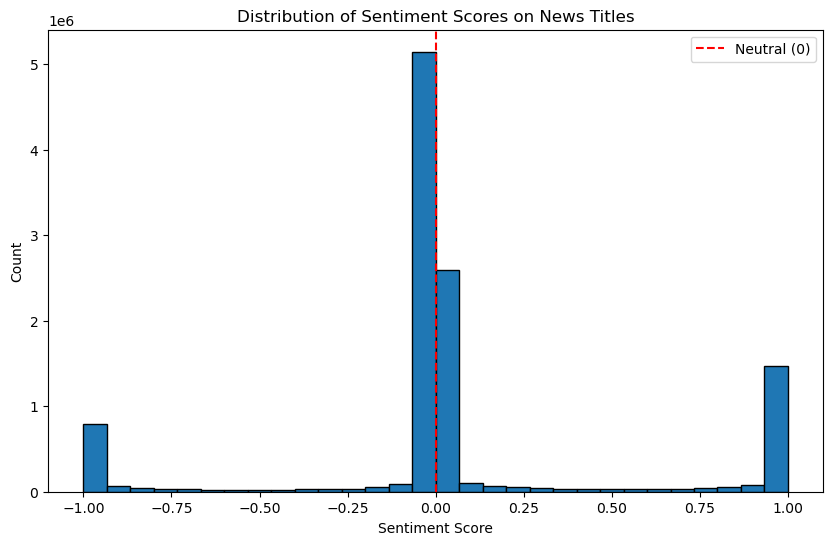


模型不确定性:
  平均不确定性: 0.258
  高不确定性样本(>0.5): 2841606 条


In [3]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("finbert_output/other/2009to2020_FNSPID_predictions.csv")

# 查看分数分布
print("情感分数分布:")
print(df['sentiment_score'].describe())

# 画直方图
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment_score'], bins=30, edgecolor='black')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Scores on News Titles')
plt.axvline(x=0, color='red', linestyle='--', label='Neutral (0)')
plt.legend()
plt.show()

# # 查看最高和最低的几个样本
# print("\n最正面样本:")
# for idx, row in df.nlargest(5, 'sentiment_score').iterrows():
#     print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# print("\n最负面样本:")
# for idx, row in df.nsmallest(5, 'sentiment_score').iterrows():
#     print(f"  Score: {row['sentiment_score']:.3f} | {row['Article_title'][:60]}")

# 查看模型的不确定性
df['uncertainty'] = 1 - df['neutral_prob']
print(f"\n模型不确定性:")
print(f"  平均不确定性: {df['uncertainty'].mean():.3f}")
print(f"  高不确定性样本(>0.5): {(df['uncertainty'] > 0.5).sum()} 条")



C:\Users\Xinny\AppData\Local\Temp\ipykernel_27680\3501100215.py:3: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  final_result_df = pd.read_csv("finbert_output/other/2009to2020_FNSPID_predictions.csv")


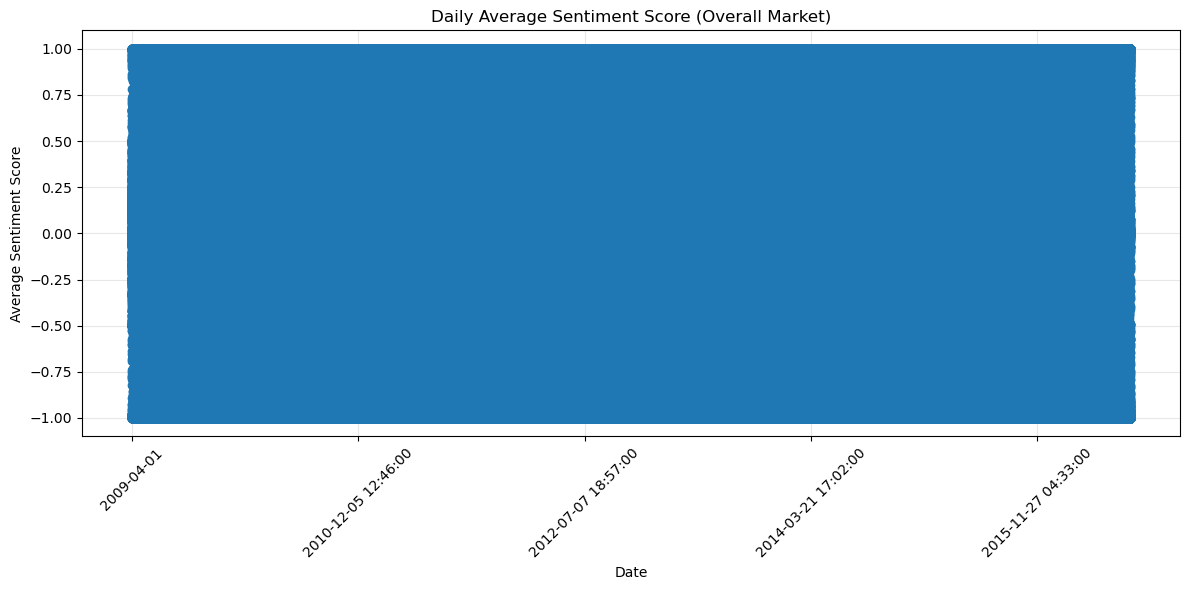

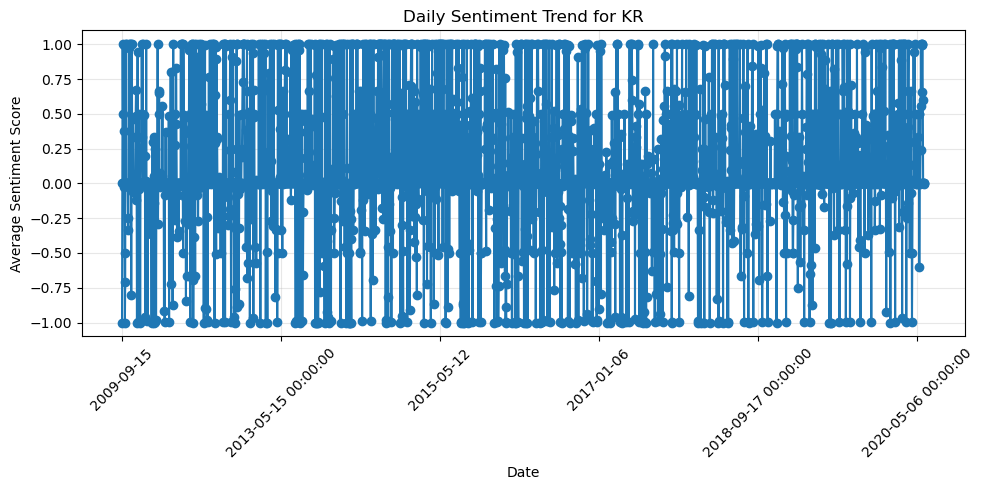

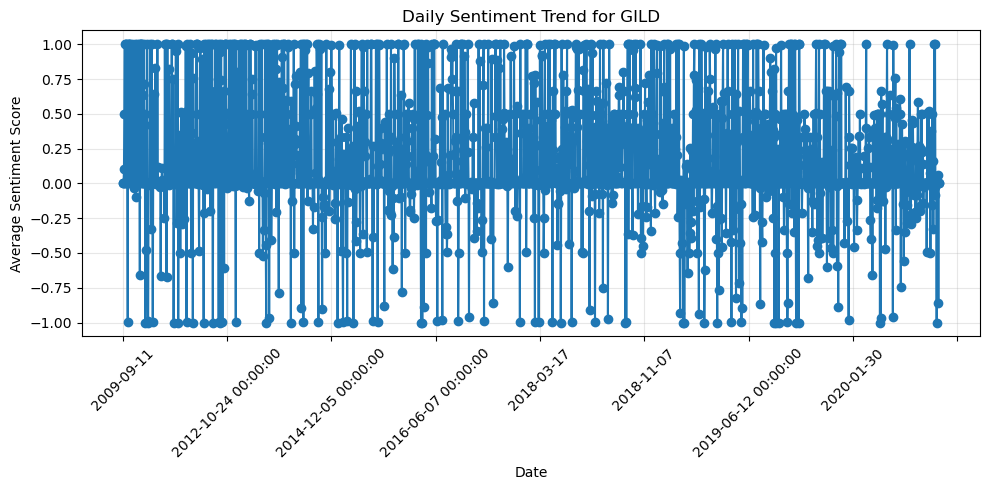

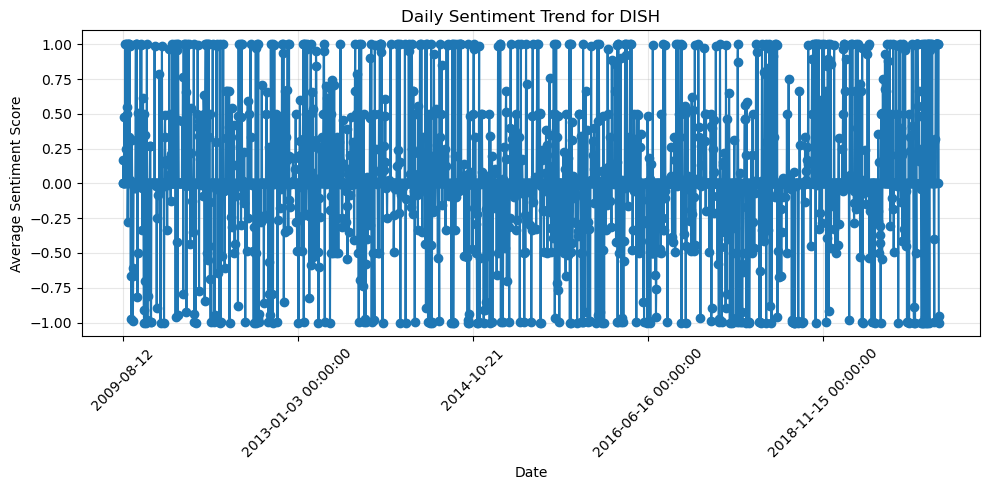

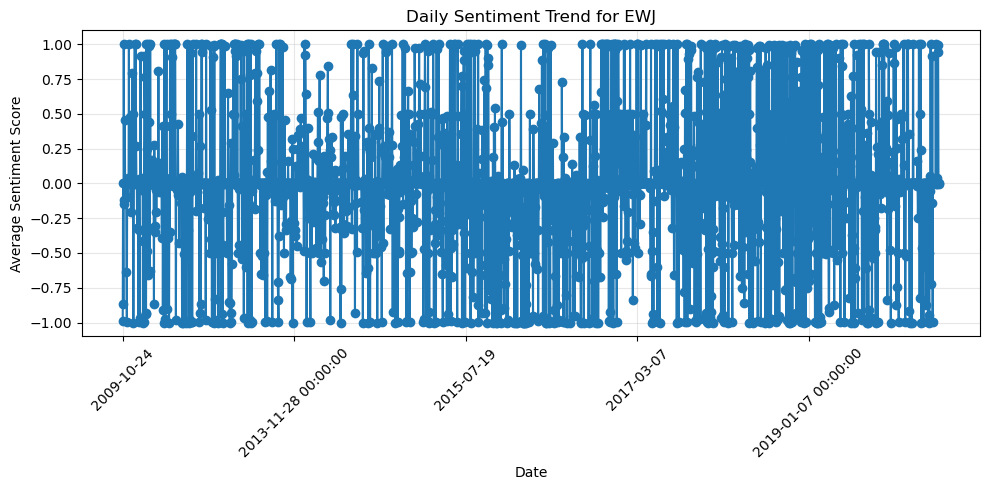

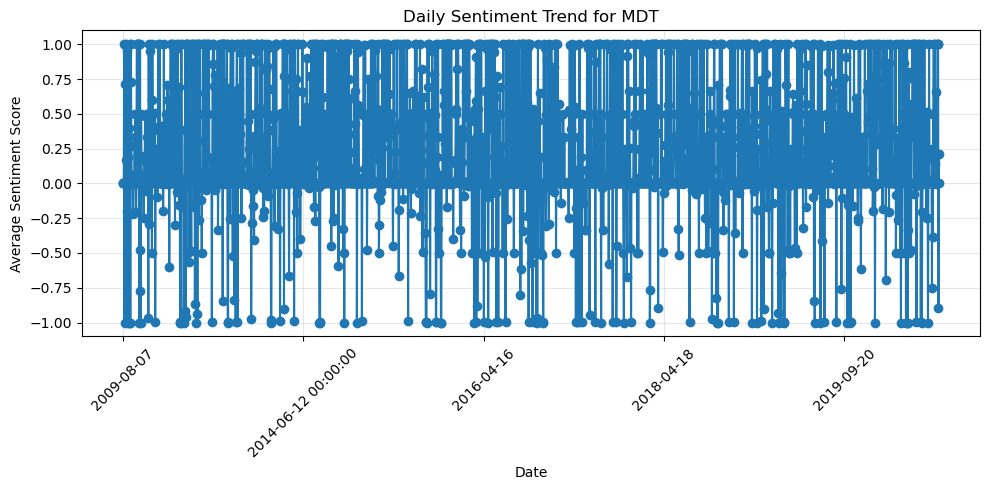

In [6]:
# 按日期分析（如果有pubDate）

final_result_df = pd.read_csv("finbert_output/other/2009to2020_FNSPID_predictions.csv")

# 绘制每日情感趋势（整体市场）
plt.figure(figsize=(12, 6))
daily_avg = final_result_df.groupby('Date')['sentiment_score'].mean()
daily_avg.plot(kind='line', marker='o')
plt.title('Daily Average Sentiment Score (Overall Market)')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 绘制特定股票的情感趋势（如果有足够数据）
top_stocks = final_result_df['Stock_symbol'].value_counts().head(5).index
for stock in top_stocks:
    stock_data = final_result_df[final_result_df['Stock_symbol'] == stock]
    if len(stock_data) > 5:  # 至少5个数据点
        daily_stock = stock_data.groupby('Date')['sentiment_score'].mean()
        plt.figure(figsize=(10, 5))
        daily_stock.plot(kind='line', marker='o')
        plt.title(f'Daily Sentiment Trend for {stock}')
        plt.xlabel('Date')
        plt.ylabel('Average Sentiment Score')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### Step 5: 股票情绪分析的必要数据统计以及数据清洗 

In [18]:
print("\n" + "="*60)
print("Step 5: 股票情绪分析的必要数据统计以及数据清洗 ")
print("="*60)

# 过滤掉没有新闻的股票（news_count = 0 或 NaN）
filtered_stock_sentiment = daily_stock_sentiment[
    (daily_stock_sentiment['news_count'] > 0) & 
    (daily_stock_sentiment['Stock_symbol'].notna())
].copy()
print(f"过滤前股票-日期组合: {len(daily_stock_sentiment)}")
print(f"过滤后有新闻的股票-日期组合: {len(filtered_stock_sentiment)}")

# 1. 每日股票新闻数量统计
print("\n" + "="*60)
print("每日股票新闻数量统计")
print("="*60)

# 每日有多少只股票有新闻
daily_stock_count = filtered_stock_sentiment.groupby('Date').size().reset_index(name='stock_count')
print(f"每日有新闻的股票数量统计:")
print(f"  平均每日: {daily_stock_count['stock_count'].mean():.2f} 只")
print(f"  最多每日: {daily_stock_count['stock_count'].max()} 只")
print(f"  最少每日: {daily_stock_count['stock_count'].min()} 只")

# 显示每日股票数量Top 10
print(f"\n每日股票数量最多的10天:")
print(daily_stock_count.nlargest(10, 'stock_count'))

# 2. 股票出现频率统计（哪些股票新闻最多）
print("\n" + "="*60)
print("股票新闻频率统计")
print("="*60)

# 统计每只股票出现的天数（有新闻的天数）
stock_frequency = filtered_stock_sentiment.groupby('Stock_symbol').agg({
    'Date': 'count',  # 有新闻的天数
    'news_count': 'sum',  # 总新闻数
    'avg_sentiment_score': 'mean'  # 平均情感分数
}).rename(columns={'Date': 'days_with_news', 'news_count': 'total_news'})

# 按有新闻的天数排序
stock_frequency_sorted = stock_frequency.sort_values('days_with_news', ascending=False)
print(f"共有 {len(stock_frequency)} 只股票有新闻")
print(f"\n新闻覆盖天数最多的前20只股票:")
print(stock_frequency_sorted.head(20))

# 3. 一周内必有新闻的股票（新闻覆盖率高）
print("\n" + "="*60)
print("一周内必有新闻的股票分析")
print("="*60)

# 计算总天数范围
total_days = len(filtered_stock_sentiment['Date'].unique())
print(f"数据总天数: {total_days} 天")

# 计算每只股票的新闻覆盖率
stock_frequency['coverage_rate'] = stock_frequency['days_with_news'] / total_days * 100

# 找出每周至少有一天有新闻的股票（覆盖率 >= 1/7 ≈ 14.3%）
weekly_coverage = stock_frequency[stock_frequency['coverage_rate'] >= (100/7)]
print(f"\n每周至少有一天有新闻的股票数量: {len(weekly_coverage)} 只")
print(f"占总股票数的比例: {len(weekly_coverage)/len(stock_frequency)*100:.1f}%")

# 找出几乎每天都有新闻的股票（覆盖率 >= 50%）
high_coverage = stock_frequency[stock_frequency['coverage_rate'] >= 50].sort_values('coverage_rate', ascending=False)
print(f"\n高覆盖率股票 (>=50%天数): {len(high_coverage)} 只")
print(high_coverage.head(20))

# 4. 每周新闻模式分析
print("\n" + "="*60)
print("每周新闻模式分析")
print("="*60)

# 添加星期几信息
filtered_stock_sentiment['Weekday'] = pd.to_datetime(filtered_stock_sentiment['Date']).dt.day_name()
filtered_stock_sentiment['Weekday_Num'] = pd.to_datetime(filtered_stock_sentiment['Date']).dt.dayofweek

# 按星期统计新闻数量
weekday_stats = filtered_stock_sentiment.groupby('Weekday_Num').agg({
    'news_count': 'sum',
    'Stock_symbol': 'nunique'  # 不同股票数量
}).reset_index()

# 映射星期名称
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekday_stats['Weekday'] = weekday_stats['Weekday_Num'].map(weekday_map)

print("\n各星期新闻发布情况:")
for _, row in weekday_stats.iterrows():
    print(f"  {row['Weekday']}: 新闻总数={row['news_count']:,}, 股票数量={row['Stock_symbol']}")

# 5. 股票情绪波动分析
print("\n" + "="*60)
print("股票情绪波动分析")
print("="*60)

# 计算每只股票的情绪波动性
stock_volatility = filtered_stock_sentiment.groupby('Stock_symbol').agg({
    'avg_sentiment_score': ['mean', 'std', 'count']
}).reset_index()

stock_volatility.columns = ['Stock_symbol', 'avg_sentiment_mean', 'sentiment_volatility', 'days_count']
stock_volatility = stock_volatility[stock_volatility['days_count'] >= 5]  # 至少5天数据

# 找出情绪最极端的股票
print("\n情绪最正面（平均分数最高）的10只股票:")
positive_stocks = stock_volatility.nlargest(10, 'avg_sentiment_mean')
for _, row in positive_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 平均={row['avg_sentiment_mean']:.4f}, 波动={row['sentiment_volatility']:.4f}, 天数={row['days_count']}")

print("\n情绪最负面（平均分数最低）的10只股票:")
negative_stocks = stock_volatility.nsmallest(10, 'avg_sentiment_mean')
for _, row in negative_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 平均={row['avg_sentiment_mean']:.4f}, 波动={row['sentiment_volatility']:.4f}, 天数={row['days_count']}")

print("\n情绪波动最大的10只股票:")
volatile_stocks = stock_volatility.nlargest(10, 'sentiment_volatility')
for _, row in volatile_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 波动={row['sentiment_volatility']:.4f}, 平均={row['avg_sentiment_mean']:.4f}, 天数={row['days_count']}")

# 6. 时间序列分析 - 每日整体市场情绪
print("\n" + "="*60)
print("每日整体市场情绪趋势")
print("="*60)

# 计算每日整体平均情绪
daily_market_sentiment = filtered_stock_sentiment.groupby('Date')['avg_sentiment_score'].mean().reset_index()
print(f"市场情绪统计:")
print(f"  整体平均: {daily_market_sentiment['avg_sentiment_score'].mean():.4f}")
print(f"  最高日情绪: {daily_market_sentiment['avg_sentiment_score'].max():.4f}")
print(f"  最低日情绪: {daily_market_sentiment['avg_sentiment_score'].min():.4f}")

# 找出情绪最极端的日期
print(f"\n市场情绪最正面的5天:")
positive_days = daily_market_sentiment.nlargest(5, 'avg_sentiment_score')
for _, row in positive_days.iterrows():
    print(f"  {row['Date'].date()}: {row['avg_sentiment_score']:.4f}")

print(f"\n市场情绪最负面的5天:")
negative_days = daily_market_sentiment.nsmallest(5, 'avg_sentiment_score')
for _, row in negative_days.iterrows():
    print(f"  {row['Date'].date()}: {row['avg_sentiment_score']:.4f}")

# 7. 保存分析结果
print("\n" + "="*60)
print("保存分析结果")
print("="*60)

os.makedirs("finbert_output/2009to2020", exist_ok=True)
output_necessary_dir = 'finbert_output/2009to2020'


# 保存清洗后的每日每只股数据
# cleaned_output = "finbert_output/2009to2020/FNSPID_daily_stock_sentiment_cleaned.csv"
cleaned_output = f"{output_necessary_dir}/FNSPID_daily_stock_sentiment_cleaned.csv"
filtered_stock_sentiment.to_csv(cleaned_output, index=False)
print(f"✅ 清洗后的每日每只股数据已保存: {cleaned_output}")

# 保存股票频率统计
# frequency_output = "finbert_output/2009to2020/FNSPID_stock_frequency.csv"
frequency_output = f"{output_necessary_dir}/FNSPID_stock_frequency.csv"
stock_frequency_sorted.to_csv(frequency_output)
print(f"✅ 股票频率统计已保存: {frequency_output}")

# 保存股票情绪波动统计
# volatility_output = "finbert_output/2009to2020/FNSPID_stock_volatility.csv"
volatility_output = f"{output_necessary_dir}/FNSPID_stock_volatility.csv"
stock_volatility.to_csv(volatility_output, index=False)
print(f"✅ 股票情绪波动统计已保存: {volatility_output}")

# 保存每日市场情绪
# market_sentiment_output = "finbert_output/2009to2020/FNSPID_market_sentiment_daily.csv"
market_sentiment_output = f"{output_necessary_dir}/FNSPID_market_sentiment_daily.csv"
daily_market_sentiment.to_csv(market_sentiment_output, index=False)
print(f"✅ 每日市场情绪已保存: {market_sentiment_output}")

print(f"\n📊 分析完成! 共分析了 {len(filtered_stock_sentiment)} 条股票-日期记录")
print(f"📈 涉及 {len(stock_frequency)} 只股票, 覆盖 {total_days} 天")


Step 5: 股票情绪分析的必要数据统计以及数据清洗 
过滤前股票-日期组合: 1913379
过滤后有新闻的股票-日期组合: 1913379

每日股票新闻数量统计
每日有新闻的股票数量统计:
  平均每日: 48.04 只
  最多每日: 1527 只
  最少每日: 1 只

每日股票数量最多的10天:
            Date  stock_count
24536 2019-11-14         1527
22819 2019-08-07         1520
24302 2019-11-07         1500
24494 2019-11-13         1465
24250 2019-11-06         1447
22701 2019-08-01         1436
18576 2018-08-01         1434
19404 2018-10-24         1392
24210 2019-11-05         1385
19389 2018-10-23         1383

股票新闻频率统计
共有 6619 只股票有新闻

新闻覆盖天数最多的前20只股票:
              days_with_news  total_news  avg_sentiment_score
Stock_symbol                                                 
KR                      1983        5126             0.106152
EWJ                     1981        4526            -0.010283
MDT                     1837        4474             0.217570
BLK                     1818        3989             0.162970
FCX                     1796        4296             0.091011
DISH                    1791       


#### 关键功能说明：

##### 1. **数据清洗**
- 过滤掉 `news_count = 0` 的记录（没有新闻的日期-股票组合）
- 过滤掉 `Stock_symbol` 为空的记录

##### 2. **股票频率分析**
- 每只股票出现的天数
- 每只股票的总新闻数
- 新闻覆盖率（出现天数/总天数）

##### 3. **一周内必有新闻的股票**
- 计算每周至少有一天有新闻的股票（覆盖率 >= 14.3%）
- 高覆盖率股票（>=50%天数）

##### 4. **每周新闻模式**
- 按星期统计新闻发布情况
- 了解哪些工作日新闻更多

##### 5. **情绪波动分析**
- 情绪最正面/最负面的股票
- 情绪波动最大的股票

##### 6. **市场情绪趋势**
- 每日整体市场情绪
- 极端情绪日识别

##### 7. **输出文件**
- `FNSPID_daily_stock_sentiment_cleaned.csv`: 清洗后的每日每只股数据
- `FNSPID_stock_frequency.csv`: 股票频率统计
- `FNSPID_stock_volatility.csv`: 股票情绪波动统计  
- `FNSPID_market_sentiment_daily.csv`: 每日市场情绪

这些分析结果可以帮助您：
- 识别重要股票（新闻覆盖率高）
- 了解新闻发布的时间模式
- 分析不同股票的情绪特征
- 为后续的股票收益预测提供特征

### Step 6: 情绪分数可视化

In [4]:
import os
import numpy
import pandas as pd


filtered_stock_sentiment = pd.read_csv('finbert_output/2009to2020/FNSPID_daily_stock_sentiment_cleaned.csv')

# 1. 每日股票新闻数量统计
print("\n" + "="*60)
print("每日股票新闻数量统计")
print("="*60)

# 每日有多少只股票有新闻
daily_stock_count = filtered_stock_sentiment.groupby('Date').size().reset_index(name='stock_count')
print(f"每日有新闻的股票数量统计:")
print(f"  平均每日: {daily_stock_count['stock_count'].mean():.2f} 只")
print(f"  最多每日: {daily_stock_count['stock_count'].max()} 只")
print(f"  最少每日: {daily_stock_count['stock_count'].min()} 只")

# 显示每日股票数量Top 10
print(f"\n每日股票数量最多的10天:")
print(daily_stock_count.nlargest(10, 'stock_count'))

# 2. 股票出现频率统计（哪些股票新闻最多）
print("\n" + "="*60)
print("股票新闻频率统计")
print("="*60)

# 统计每只股票出现的天数（有新闻的天数）
stock_frequency = filtered_stock_sentiment.groupby('Stock_symbol').agg({
    'Date': 'count',  # 有新闻的天数
    'news_count': 'sum',  # 总新闻数
    'avg_sentiment_score': 'mean'  # 平均情感分数
}).rename(columns={'Date': 'days_with_news', 'news_count': 'total_news'})

# 按有新闻的天数排序
stock_frequency_sorted = stock_frequency.sort_values('days_with_news', ascending=False)
print(f"共有 {len(stock_frequency)} 只股票有新闻")
print(f"\n新闻覆盖天数最多的前20只股票:")
print(stock_frequency_sorted.head(20))

# 3. 一周内必有新闻的股票（新闻覆盖率高）
print("\n" + "="*60)
print("一周内必有新闻的股票分析")
print("="*60)

# 计算总天数范围
total_days = len(filtered_stock_sentiment['Date'].unique())
print(f"数据总天数: {total_days} 天")

# 计算每只股票的新闻覆盖率
stock_frequency['coverage_rate'] = stock_frequency['days_with_news'] / total_days * 100

# 找出每周至少有一天有新闻的股票（覆盖率 >= 1/7 ≈ 14.3%）
weekly_coverage = stock_frequency[stock_frequency['coverage_rate'] >= (100/7)]
print(f"\n每周至少有一天有新闻的股票数量: {len(weekly_coverage)} 只")
print(f"占总股票数的比例: {len(weekly_coverage)/len(stock_frequency)*100:.1f}%")

# 找出几乎每天都有新闻的股票（覆盖率 >= 50%）
high_coverage = stock_frequency[stock_frequency['coverage_rate'] >= 50].sort_values('coverage_rate', ascending=False)
print(f"\n高覆盖率股票 (>=50%天数): {len(high_coverage)} 只")
print(high_coverage.head(20))

# 4. 每周新闻模式分析
print("\n" + "="*60)
print("每周新闻模式分析")
print("="*60)

# 一次性转换所有日期
filtered_stock_sentiment['Date_DT'] = pd.to_datetime(
    filtered_stock_sentiment['Date'].str[:10],  # 只取日期部分
    format='%Y-%m-%d'
)

# 然后提取星期信息
filtered_stock_sentiment['Weekday'] = filtered_stock_sentiment['Date_DT'].dt.day_name()
filtered_stock_sentiment['Weekday_Num'] = filtered_stock_sentiment['Date_DT'].dt.dayofweek

# 可选：删除临时列
# filtered_stock_sentiment = filtered_stock_sentiment.drop('Date_DT', axis=1)

# 添加星期几信息
# filtered_stock_sentiment['Weekday'] = pd.to_datetime(filtered_stock_sentiment['Date']).dt.day_name()
# filtered_stock_sentiment['Weekday_Num'] = pd.to_datetime(filtered_stock_sentiment['Date']).dt.dayofweek

# 按星期统计新闻数量
weekday_stats = filtered_stock_sentiment.groupby('Weekday_Num').agg({
    'news_count': 'sum',
    'Stock_symbol': 'nunique'  # 不同股票数量
}).reset_index()

# 映射星期名称
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekday_stats['Weekday'] = weekday_stats['Weekday_Num'].map(weekday_map)

print("\n各星期新闻发布情况:")
for _, row in weekday_stats.iterrows():
    print(f"  {row['Weekday']}: 新闻总数={row['news_count']:,}, 股票数量={row['Stock_symbol']}")

# 5. 股票情绪波动分析
print("\n" + "="*60)
print("股票情绪波动分析")
print("="*60)

# 计算每只股票的情绪波动性
stock_volatility = filtered_stock_sentiment.groupby('Stock_symbol').agg({
    'avg_sentiment_score': ['mean', 'std', 'count']
}).reset_index()

stock_volatility.columns = ['Stock_symbol', 'avg_sentiment_mean', 'sentiment_volatility', 'days_count']
stock_volatility = stock_volatility[stock_volatility['days_count'] >= 5]  # 至少5天数据

# 找出情绪最极端的股票
print("\n情绪最正面（平均分数最高）的10只股票:")
positive_stocks = stock_volatility.nlargest(10, 'avg_sentiment_mean')
for _, row in positive_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 平均={row['avg_sentiment_mean']:.4f}, 波动={row['sentiment_volatility']:.4f}, 天数={row['days_count']}")

print("\n情绪最负面（平均分数最低）的10只股票:")
negative_stocks = stock_volatility.nsmallest(10, 'avg_sentiment_mean')
for _, row in negative_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 平均={row['avg_sentiment_mean']:.4f}, 波动={row['sentiment_volatility']:.4f}, 天数={row['days_count']}")

print("\n情绪波动最大的10只股票:")
volatile_stocks = stock_volatility.nlargest(10, 'sentiment_volatility')
for _, row in volatile_stocks.iterrows():
    print(f"  {row['Stock_symbol']}: 波动={row['sentiment_volatility']:.4f}, 平均={row['avg_sentiment_mean']:.4f}, 天数={row['days_count']}")

# 6. 时间序列分析 - 每日整体市场情绪
print("\n" + "="*60)
print("每日整体市场情绪趋势")
print("="*60)

# 计算每日整体平均情绪
daily_market_sentiment = filtered_stock_sentiment.groupby('Date')['avg_sentiment_score'].mean().reset_index()
print(f"市场情绪统计:")
print(f"  整体平均: {daily_market_sentiment['avg_sentiment_score'].mean():.4f}")
print(f"  最高日情绪: {daily_market_sentiment['avg_sentiment_score'].max():.4f}")
print(f"  最低日情绪: {daily_market_sentiment['avg_sentiment_score'].min():.4f}")

# 找出情绪最极端的日期
print(f"\n市场情绪最正面的5天:")
positive_days = daily_market_sentiment.nlargest(5, 'avg_sentiment_score')
for _, row in positive_days.iterrows():
    date_str = pd.to_datetime(row['Date']).strftime('%Y-%m-%d')
    print(f"  {date_str}: {row['avg_sentiment_score']:.4f}")

print(f"\n市场情绪最负面的5天:")
negative_days = daily_market_sentiment.nsmallest(5, 'avg_sentiment_score')
for _, row in negative_days.iterrows():
    date_str = pd.to_datetime(row['Date']).strftime('%Y-%m-%d')
    print(f"  {date_str}: {row['avg_sentiment_score']:.4f}")
    # print(f"  {row['Date'].date()}: {row['avg_sentiment_score']:.4f}")




每日股票新闻数量统计
每日有新闻的股票数量统计:
  平均每日: 48.04 只
  最多每日: 1527 只
  最少每日: 1 只

每日股票数量最多的10天:
                      Date  stock_count
24537  2019-11-14 00:00:00         1527
22820  2019-08-07 00:00:00         1520
24303  2019-11-07 00:00:00         1500
24495  2019-11-13 00:00:00         1465
24251  2019-11-06 00:00:00         1447
22702  2019-08-01 00:00:00         1436
18577  2018-08-01 00:00:00         1434
19405  2018-10-24 00:00:00         1392
24211  2019-11-05 00:00:00         1385
19390  2018-10-23 00:00:00         1383

股票新闻频率统计
共有 6619 只股票有新闻

新闻覆盖天数最多的前20只股票:
              days_with_news  total_news  avg_sentiment_score
Stock_symbol                                                 
KR                      1983        5126             0.106152
EWJ                     1981        4526            -0.010283
MDT                     1837        4474             0.217570
BLK                     1818        3989             0.162970
FCX                     1796        4296             0.091011

In [2]:
# 在绘图前统一处理日期格式
if 'Date' in daily_market_sentiment.columns:
    # 检查日期列类型
    if not pd.api.types.is_datetime64_any_dtype(daily_market_sentiment['Date']):
        # 如果是字符串，提取日期部分并转换
        daily_market_sentiment['Date'] = pd.to_datetime(
            daily_market_sentiment['Date'].astype(str).str[:10],
            format='%Y-%m-%d'
        )
        print("日期列已转换")
    print(f"日期范围: {daily_market_sentiment['Date'].min()} 到 {daily_market_sentiment['Date'].max()}")


日期列已转换
日期范围: 2009-04-27 00:00:00 到 2020-06-10 00:00:00


In [ ]:
print("\n" + "="*60)
print("Step 6: 情绪分数可视化")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-darkgrid')

# 创建图表目录
os.makedirs("finbert_output/2009to2020/figures", exist_ok=True)
output_necessary_figures_dir = 'finbert_output/2009to2020/figures'



#### 1: 股票新闻覆盖频率分布

In [19]:
# 设置全局样式
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 14


图1: 绘制股票新闻覆盖频率分布...


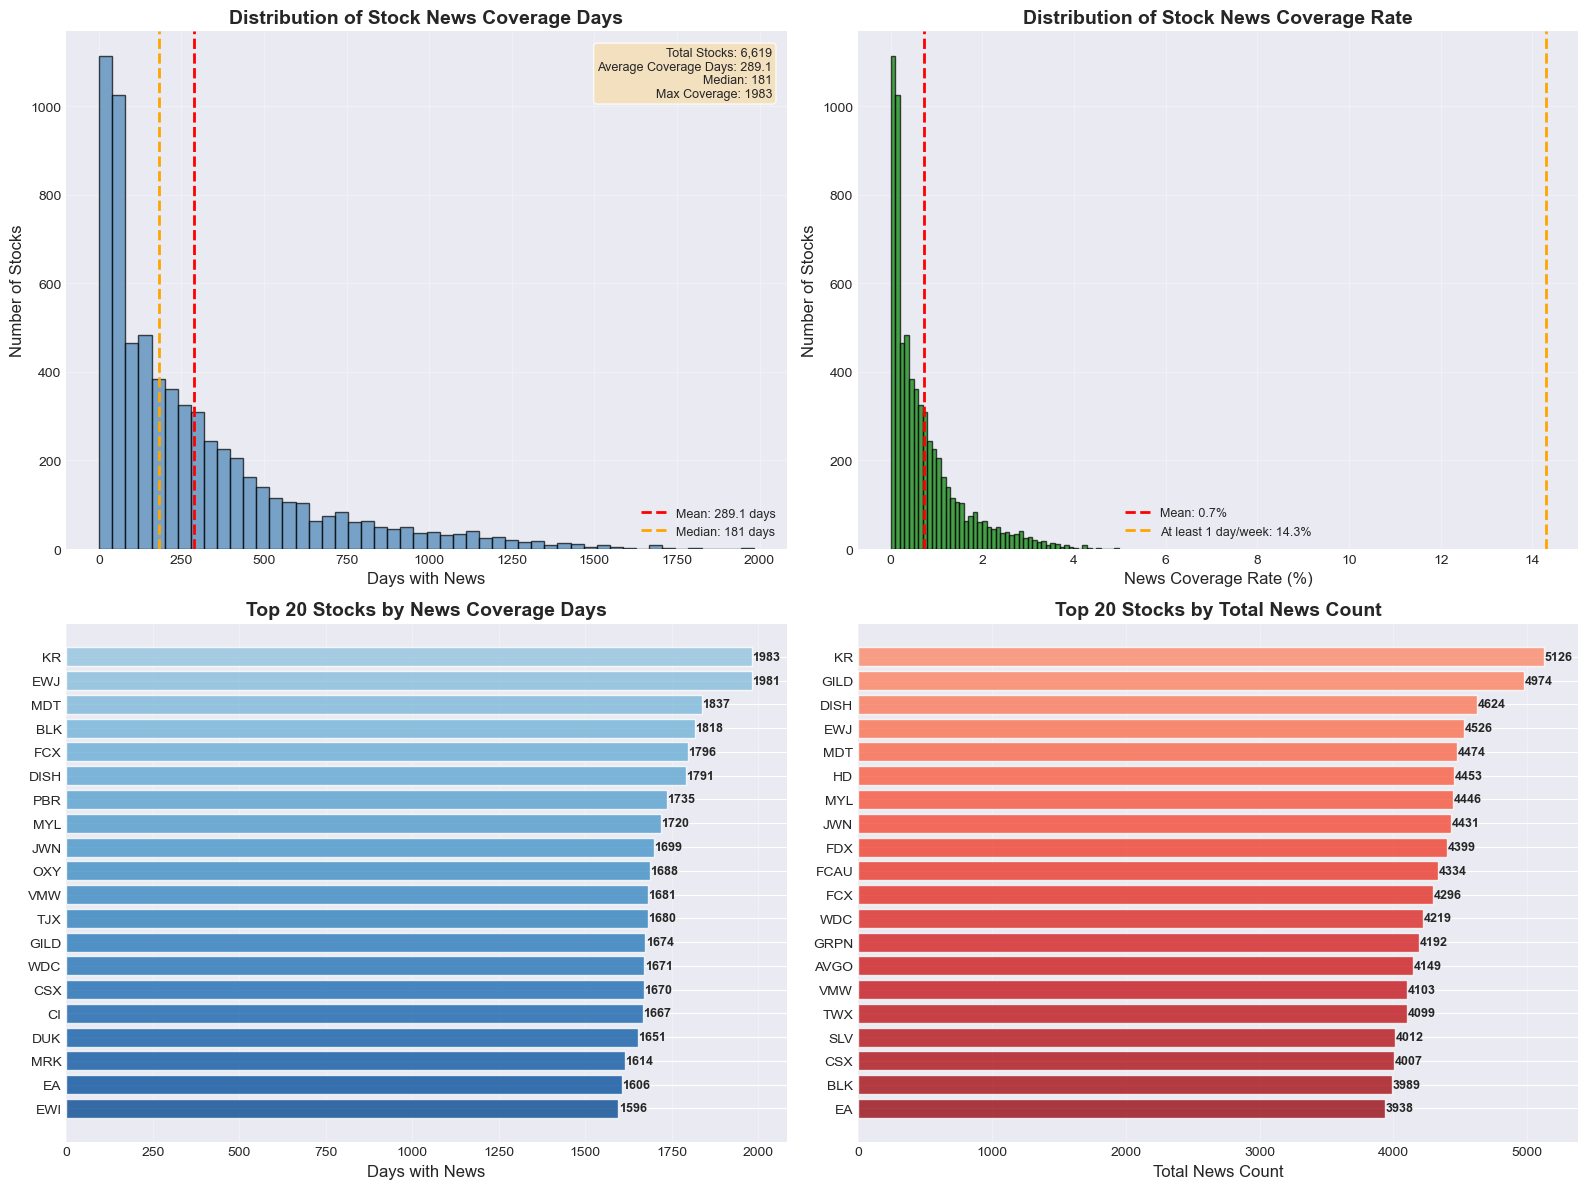

✅ 图1保存完成


In [22]:
# ============================================
# 图1: 股票新闻覆盖频率分布（优化版）
# ============================================
print("\n" + "="*60)
print("图1: 绘制股票新闻覆盖频率分布...")
print("="*60)

fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))

# 1.1 股票出现天数分布
ax1 = axes1[0, 0]
stock_frequency['days_with_news'].hist(bins=50, edgecolor='black', alpha=0.7, 
                                        color='steelblue', ax=ax1)
mean_days = stock_frequency['days_with_news'].mean()
median_days = stock_frequency['days_with_news'].median()
ax1.axvline(mean_days, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_days:.1f} days')
ax1.axvline(median_days, color='orange', linestyle='--', linewidth=2, 
            label=f'Median: {median_days:.0f} days')
ax1.set_xlabel('Days with News', fontsize=12)
ax1.set_ylabel('Number of Stocks', fontsize=12)
ax1.set_title('Distribution of Stock News Coverage Days', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 添加统计信息框
stats_text = f"Total Stocks: {len(stock_frequency):,}\n"
stats_text += f"Average Coverage Days: {mean_days:.1f}\n"
stats_text += f"Median: {median_days:.0f}\n"
stats_text += f"Max Coverage: {stock_frequency['days_with_news'].max():.0f}"
ax1.text(0.98, 0.97, stats_text, transform=ax1.transAxes, 
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 1.2 股票覆盖率分布
ax2 = axes1[0, 1]
stock_frequency['coverage_rate'].hist(bins=50, edgecolor='black', alpha=0.7, 
                                       color='green', ax=ax2)
mean_rate = stock_frequency['coverage_rate'].mean()
ax2.axvline(mean_rate, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {mean_rate:.1f}%')
ax2.axvline(100/7, color='orange', linestyle='--', linewidth=2,
            label=f'At least 1 day/week: {100/7:.1f}%')
ax2.set_xlabel('News Coverage Rate (%)', fontsize=12)
ax2.set_ylabel('Number of Stocks', fontsize=12)
ax2.set_title('Distribution of Stock News Coverage Rate', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 1.3 Top 20 股票新闻覆盖天数
ax3 = axes1[1, 0]
top20_stocks = stock_frequency_sorted.head(20)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top20_stocks)))
bars = ax3.barh(range(len(top20_stocks)), top20_stocks['days_with_news'].values, 
                color=colors, alpha=0.8)
ax3.set_yticks(range(len(top20_stocks)))
ax3.set_yticklabels(top20_stocks.index, fontsize=10)
ax3.set_xlabel('Days with News', fontsize=12)
ax3.set_title('Top 20 Stocks by News Coverage Days', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, top20_stocks['days_with_news'].values)):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(val)}', va='center', fontsize=9, fontweight='bold')

# 1.4 总新闻数 Top 20
ax4 = axes1[1, 1]
top20_news = stock_frequency_sorted.nlargest(20, 'total_news')
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top20_news)))
bars = ax4.barh(range(len(top20_news)), top20_news['total_news'].values, 
                color=colors, alpha=0.8)
ax4.set_yticks(range(len(top20_news)))
ax4.set_yticklabels(top20_news.index, fontsize=10)
ax4.set_xlabel('Total News Count', fontsize=12)
ax4.set_title('Top 20 Stocks by Total News Count', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, top20_news['total_news'].values)):
    ax4.text(val + 5, bar.get_y() + bar.get_height()/2, 
             f'{int(val)}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_necessary_figures_dir}/01_stock_coverage_distribution.png', 
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ 图1保存完成")

**1. 图1：股票新闻覆盖频率分布**
- **左上图**：看大多数股票的新闻覆盖天数集中在哪个区间
  - 如果右偏（长尾），说明少数股票新闻很多
  - 如果集中在左侧，说明大部分股票新闻较少
  
- **右上图**：看覆盖率分布
  - 平均值越高，说明股票新闻覆盖越普遍
  - 橙色线（每周至少1天）可以判断是否达到基本覆盖

- **左下/右下图**：识别新闻最多的明星股
  - 关注这些股票，它们可能是市场热点

#### 2: 每周新闻模式分析


图2: 绘制每周新闻模式分析...


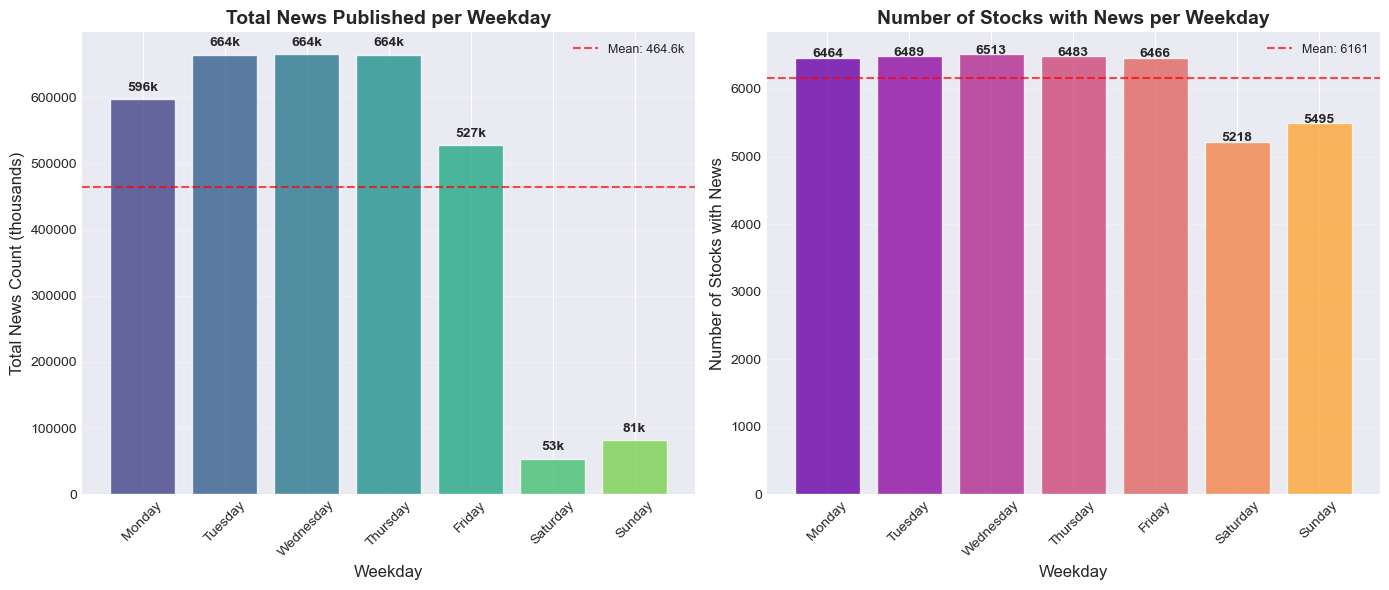

✅ 图2保存完成


In [24]:
print("\n" + "="*60)
print("图2: 绘制每周新闻模式分析...")
print("="*60)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

# 2.1 按星期统计新闻总数
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats['Weekday'] = pd.Categorical(weekday_stats['Weekday'], 
                                          categories=weekday_order, ordered=True)
weekday_stats_sorted = weekday_stats.sort_values('Weekday')

ax1 = axes2[0]
bars = ax1.bar(weekday_stats_sorted['Weekday'], weekday_stats_sorted['news_count'], 
               color=plt.cm.viridis(np.linspace(0.2, 0.8, 7)), alpha=0.8)
ax1.set_xlabel('Weekday', fontsize=12)
ax1.set_ylabel('Total News Count (thousands)', fontsize=12)
ax1.set_title('Total News Published per Weekday', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# 动态数值标签
max_height = weekday_stats_sorted['news_count'].max()
for bar, val in zip(bars, weekday_stats_sorted['news_count']):
    offset = max_height * 0.02
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset, 
             f'{int(val/1000)}k', ha='center', fontsize=10, fontweight='bold')

# 添加平均线
avg_news = weekday_stats_sorted['news_count'].mean()
ax1.axhline(y=avg_news, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Mean: {avg_news/1000:.1f}k')
ax1.legend()

# 2.2 按星期统计股票数量
ax2 = axes2[1]
bars = ax2.bar(weekday_stats_sorted['Weekday'], weekday_stats_sorted['Stock_symbol'], 
               color=plt.cm.plasma(np.linspace(0.2, 0.8, 7)), alpha=0.8)
ax2.set_xlabel('Weekday', fontsize=12)
ax2.set_ylabel('Number of Stocks with News', fontsize=12)
ax2.set_title('Number of Stocks with News per Weekday', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, weekday_stats_sorted['Stock_symbol']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{int(val)}', ha='center', fontsize=10, fontweight='bold')

avg_stocks = weekday_stats_sorted['Stock_symbol'].mean()
ax2.axhline(y=avg_stocks, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Mean: {avg_stocks:.0f}')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{output_necessary_figures_dir}/02_weekly_pattern.png', 
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ 图2保存完成")

**图2：每周新闻模式**
- **左图**：找出新闻发布高峰日（通常周中最多）
- **右图**：看哪一天有最多股票被报道
- **关键洞察**：如果周末新闻量显著少于工作日，说明周末可以放松监测


#### 3: 股票情绪分析


图3: 绘制股票情绪分析...


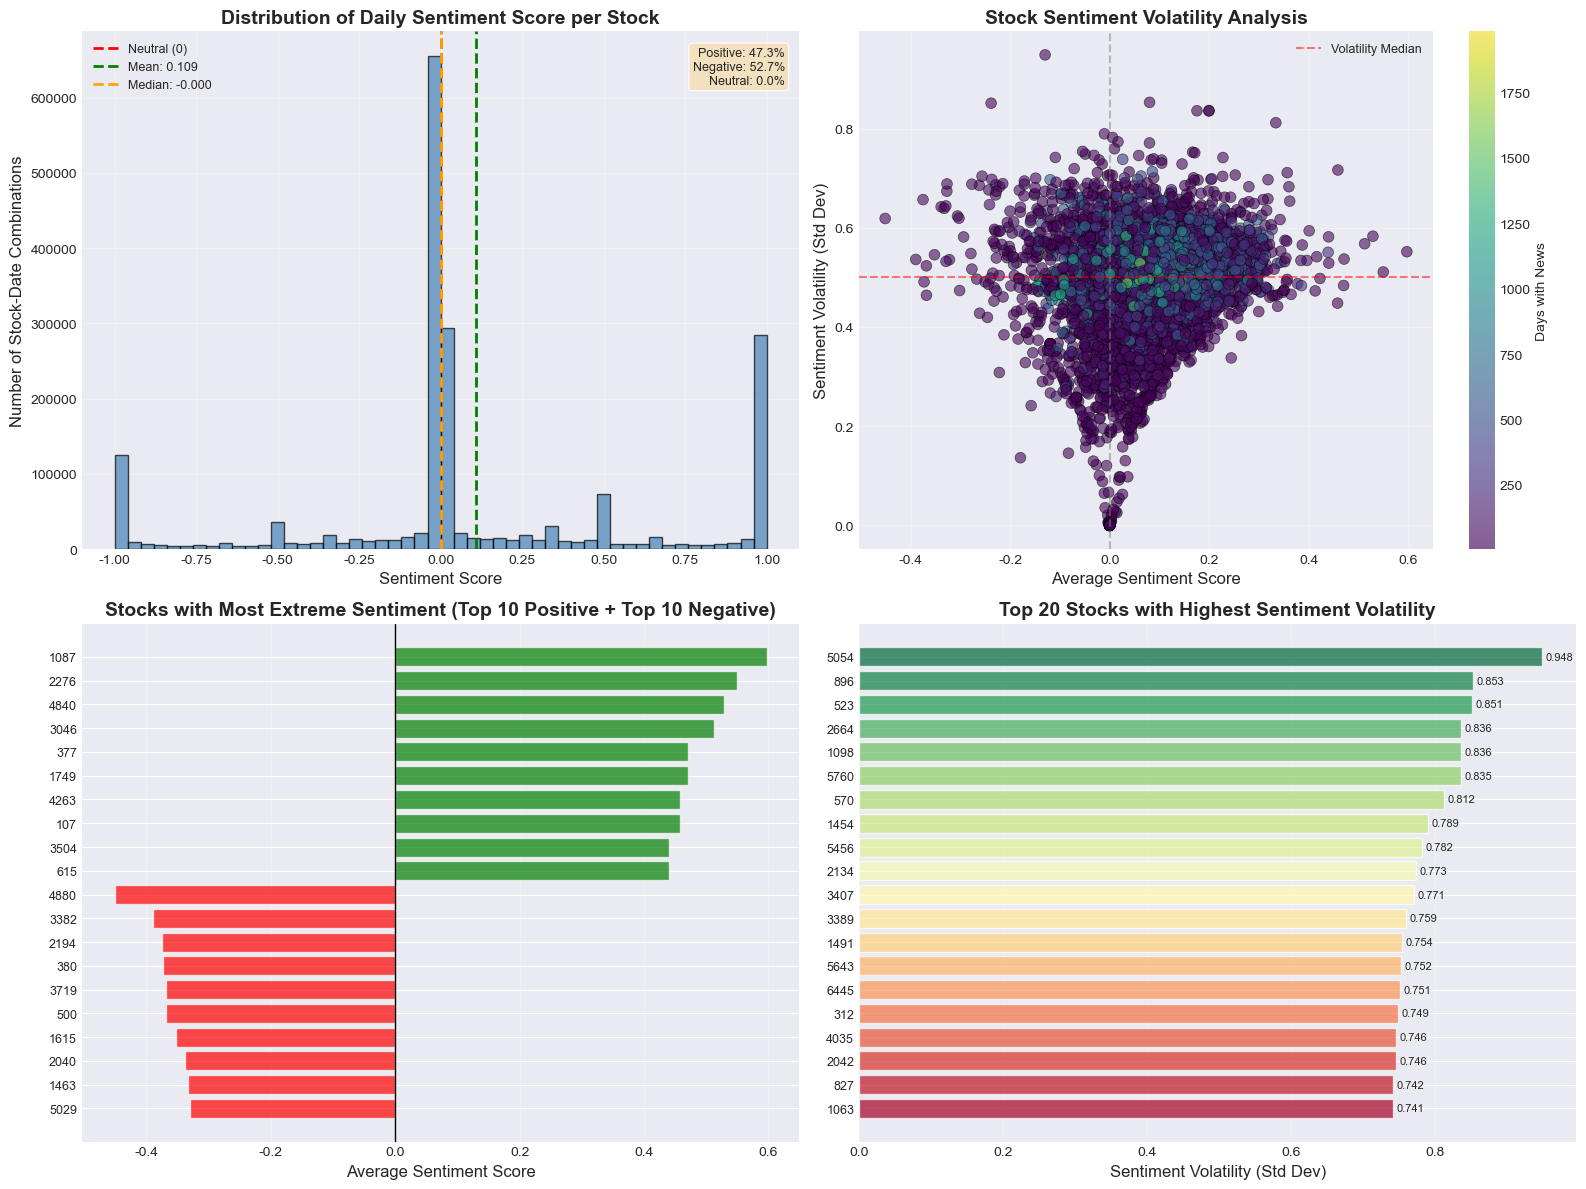

✅ 图3保存完成


In [26]:
# ============================================
# 图3: 股票情绪分析（优化版）
# ============================================
print("\n" + "="*60)
print("图3: 绘制股票情绪分析...")
print("="*60)

fig3, axes3 = plt.subplots(2, 2, figsize=(16, 12))

# 3.1 情绪分数分布
ax1 = axes3[0, 0]
sentiment_scores = filtered_stock_sentiment['avg_sentiment_score']
sentiment_scores.hist(bins=50, edgecolor='black', alpha=0.7, 
                      color='steelblue', ax=ax1)
mean_score = sentiment_scores.mean()
median_score = sentiment_scores.median()
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral (0)')
ax1.axvline(mean_score, color='green', linestyle='--', linewidth=2,
            label=f'Mean: {mean_score:.3f}')
ax1.axvline(median_score, color='orange', linestyle='--', linewidth=2,
            label=f'Median: {median_score:.3f}')
ax1.set_xlabel('Sentiment Score', fontsize=12)
ax1.set_ylabel('Number of Stock-Date Combinations', fontsize=12)
ax1.set_title('Distribution of Daily Sentiment Score per Stock', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 添加统计信息
positive_pct = (sentiment_scores > 0).sum() / len(sentiment_scores) * 100
negative_pct = (sentiment_scores < 0).sum() / len(sentiment_scores) * 100
neutral_pct = (sentiment_scores == 0).sum() / len(sentiment_scores) * 100
stats_text = f"Positive: {positive_pct:.1f}%\n"
stats_text += f"Negative: {negative_pct:.1f}%\n"
stats_text += f"Neutral: {neutral_pct:.1f}%"
ax1.text(0.98, 0.97, stats_text, transform=ax1.transAxes, 
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 3.2 情绪波动 vs 平均情绪
ax2 = axes3[0, 1]
scatter = ax2.scatter(stock_volatility['avg_sentiment_mean'], 
                      stock_volatility['sentiment_volatility'],
                      c=stock_volatility['days_count'], 
                      cmap='viridis', alpha=0.6, s=60, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Average Sentiment Score', fontsize=12)
ax2.set_ylabel('Sentiment Volatility (Std Dev)', fontsize=12)
ax2.set_title('Stock Sentiment Volatility Analysis', fontsize=14, fontweight='bold')
ax2.axhline(y=stock_volatility['sentiment_volatility'].median(), 
            color='red', linestyle='--', alpha=0.5, label='Volatility Median')
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Days with News', fontsize=10)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3.3 情绪最极端的股票
ax3 = axes3[1, 0]
top_positive = stock_volatility.nlargest(10, 'avg_sentiment_mean')
top_negative = stock_volatility.nsmallest(10, 'avg_sentiment_mean')
extreme_stocks = pd.concat([top_positive, top_negative])
colors = ['green'] * 10 + ['red'] * 10
bars = ax3.barh(range(len(extreme_stocks)), extreme_stocks['avg_sentiment_mean'].values, 
                color=colors, alpha=0.7)
ax3.set_yticks(range(len(extreme_stocks)))
ax3.set_yticklabels(extreme_stocks.index, fontsize=9)
ax3.set_xlabel('Average Sentiment Score', fontsize=12)
ax3.set_title('Stocks with Most Extreme Sentiment (Top 10 Positive + Top 10 Negative)', fontsize=14, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# 3.4 情绪波动最大的股票
ax4 = axes3[1, 1]
top_volatile = stock_volatility.nlargest(20, 'sentiment_volatility')
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_volatile)))
bars = ax4.barh(range(len(top_volatile)), top_volatile['sentiment_volatility'].values, 
                color=colors, alpha=0.7)
ax4.set_yticks(range(len(top_volatile)))
ax4.set_yticklabels(top_volatile.index, fontsize=9)
ax4.set_xlabel('Sentiment Volatility (Std Dev)', fontsize=12)
ax4.set_title('Top 20 Stocks with Highest Sentiment Volatility', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, top_volatile['sentiment_volatility'].values)):
    ax4.text(val + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{output_necessary_figures_dir}/03_stock_sentiment_analysis.png', 
            dpi=200, bbox_inches='tight')
plt.show()
print("✅ 图3保存完成")




**图3：股票情绪分析**
- **左上图**：情绪分布是否对称？
  - 右偏 → 整体乐观
  - 左偏 → 整体悲观
  
- **右上图**：识别高波动股票（右上角）
  - 这些股票情绪不稳定，风险较高
  
- **左下图**：关注极端情绪股票
  - 绿色：持续正面，可能值得投资
  - 红色：持续负面，需要规避
  
- **右下图**：波动最大的股票
  - 适合短线交易者，不适合长期持有

#### 4. 市场情绪时间序列

数据预处理...
原始 Date 列类型: datetime64[ns]
原始数据量: 39,831 行
转换后数据量: 39,831 行
日期范围: 2009-04-27 00:00:00 到 2020-06-10 00:00:00

数据量较大，进行采样优化...
采样后数据量: 135 行

开始绘图...

处理股票数据...
股票数据量较大 (3,982 行)，进行采样...
采样后数据量: 135 行

✅ 图片已保存: finbert_output/2019to2020/figures/04_market_sentiment_trend.png


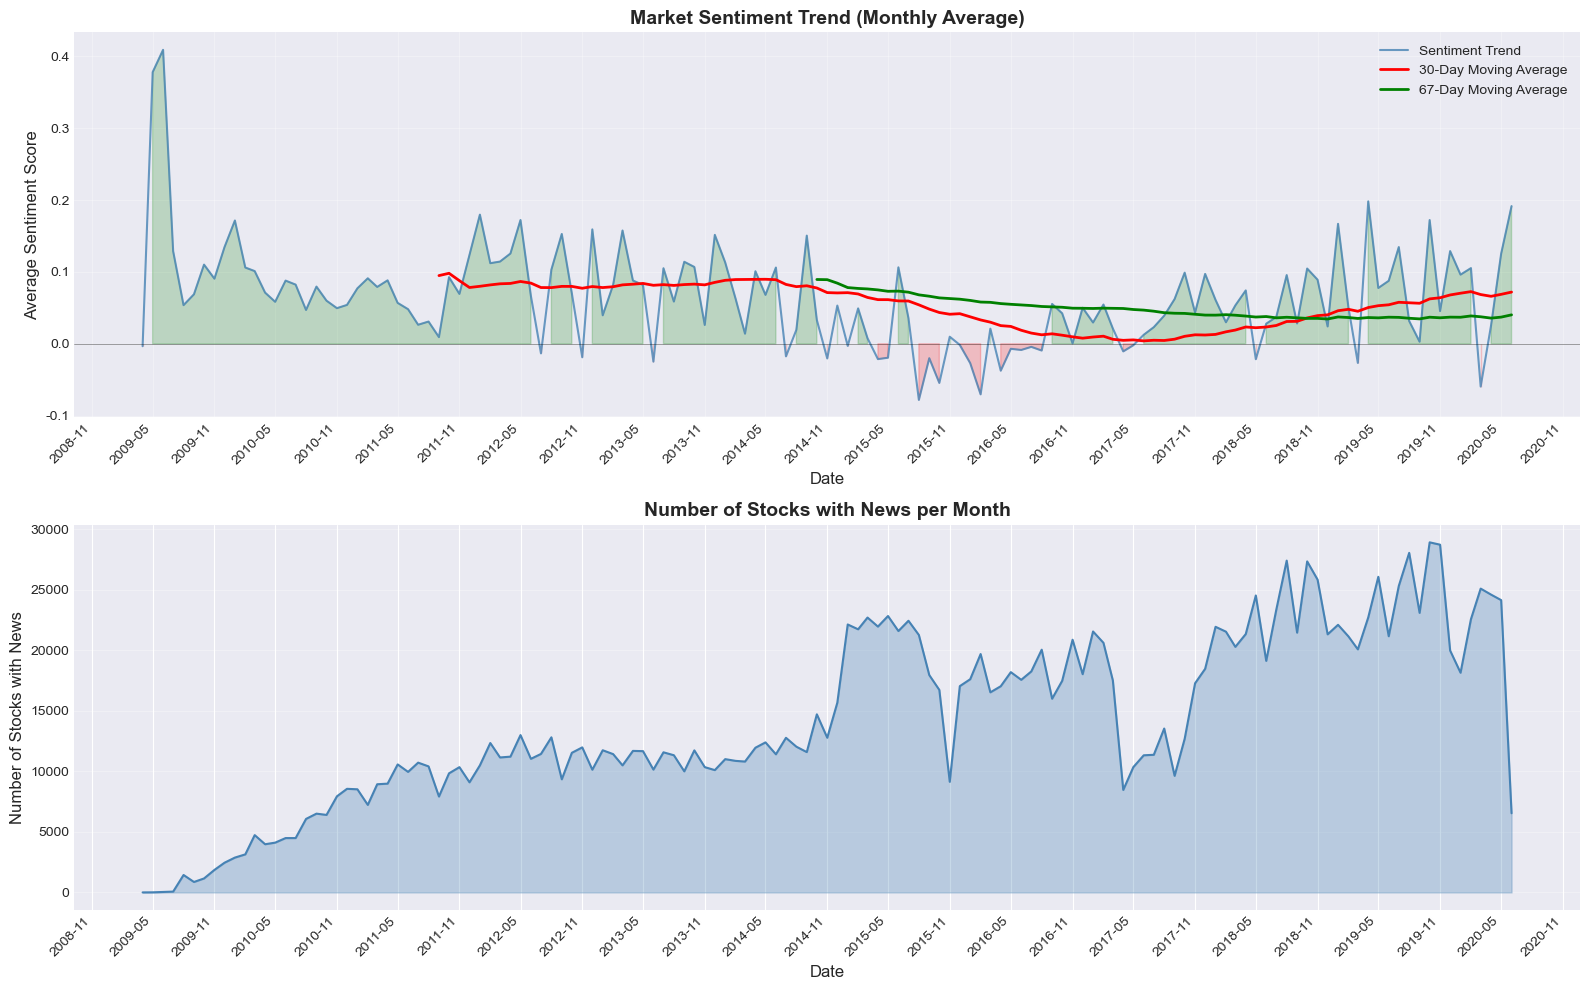

✅ 图表绘制完成！


In [27]:

# ============================================
# 4. 市场情绪时间序列（优化版 - 修复采样问题）-all data时候用
# ============================================
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 数据预处理和采样
print("="*50)
print("数据预处理...")
print("="*50)

# 确保 Date 列是 datetime 类型
print(f"原始 Date 列类型: {daily_market_sentiment['Date'].dtype}")
print(f"原始数据量: {len(daily_market_sentiment):,} 行")

# 转换日期格式
daily_market_sentiment['Date'] = pd.to_datetime(
    daily_market_sentiment['Date'].astype(str).str[:10],
    format='%Y-%m-%d',
    errors='coerce'
)

# 删除无效日期
daily_market_sentiment = daily_market_sentiment.dropna(subset=['Date'])
print(f"转换后数据量: {len(daily_market_sentiment):,} 行")
print(f"日期范围: {daily_market_sentiment['Date'].min()} 到 {daily_market_sentiment['Date'].max()}")

# 数据采样
if len(daily_market_sentiment) > 2000:
    print("\n数据量较大，进行采样优化...")
    
    # 方法：按月采样（使用 groupby，更稳定）
    daily_market_sentiment['YearMonth'] = daily_market_sentiment['Date'].dt.to_period('M')
    
    plot_data = (daily_market_sentiment
                 .groupby('YearMonth', as_index=False)
                 .agg({'avg_sentiment_score': 'mean'})
                 .rename(columns={'YearMonth': 'Date'}))
    
    # 将 Period 转换为 datetime
    plot_data['Date'] = plot_data['Date'].dt.to_timestamp()
    
    print(f"采样后数据量: {len(plot_data):,} 行")
else:
    plot_data = daily_market_sentiment.copy()
    print("\n数据量适中，使用原始数据")

print("\n开始绘图...")

# 4.1 每日市场情绪趋势
ax1 = axes[0]

# 绘制线图
ax1.plot(plot_data['Date'], plot_data['avg_sentiment_score'], 
         linewidth=1.5, color='steelblue', alpha=0.8, label='Sentiment Trend')

# 计算移动平均（使用采样后的数据）
window_30 = min(30, len(plot_data) // 3)
window_90 = min(90, len(plot_data) // 2)

if window_30 > 1:
    ma_30 = plot_data['avg_sentiment_score'].rolling(window=window_30).mean()
    ax1.plot(plot_data['Date'], ma_30, linewidth=2, color='red', 
             label=f'{window_30}-Day Moving Average')
if window_90 > 1:
    ma_90 = plot_data['avg_sentiment_score'].rolling(window=window_90).mean()
    ax1.plot(plot_data['Date'], ma_90, linewidth=2, color='green', 
             label=f'{window_90}-Day Moving Average')

# 填充正负区域
positive_mask = plot_data['avg_sentiment_score'] > 0
negative_mask = plot_data['avg_sentiment_score'] < 0

if positive_mask.any():
    ax1.fill_between(plot_data['Date'], 0, plot_data['avg_sentiment_score'],
                      where=positive_mask, color='green', alpha=0.2)
if negative_mask.any():
    ax1.fill_between(plot_data['Date'], 0, plot_data['avg_sentiment_score'],
                      where=negative_mask, color='red', alpha=0.2)

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Average Sentiment Score', fontsize=12)
ax1.set_title('Market Sentiment Trend (Monthly Average)', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# 优化x轴刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4.2 每日有新闻的股票数量
ax2 = axes[1]

# 确保 filtered_stock_sentiment 的日期格式正确
print("\n处理股票数据...")
if 'Date' in filtered_stock_sentiment.columns:
    if not pd.api.types.is_datetime64_any_dtype(filtered_stock_sentiment['Date']):
        filtered_stock_sentiment['Date'] = pd.to_datetime(
            filtered_stock_sentiment['Date'].astype(str).str[:10],
            format='%Y-%m-%d',
            errors='coerce'
        )
    
    # 计算每日股票数量
    daily_stock_count = filtered_stock_sentiment.groupby('Date').size().reset_index(name='stock_count')
    daily_stock_count = daily_stock_count.dropna(subset=['Date'])
    
    # 如果数据量太大，也进行采样
    if len(daily_stock_count) > 2000:
        print(f"股票数据量较大 ({len(daily_stock_count):,} 行)，进行采样...")
        daily_stock_count['YearMonth'] = daily_stock_count['Date'].dt.to_period('M')
        stock_count_monthly = (daily_stock_count
                               .groupby('YearMonth', as_index=False)
                               .agg({'stock_count': 'sum'})
                               .rename(columns={'YearMonth': 'Date'}))
        stock_count_monthly['Date'] = stock_count_monthly['Date'].dt.to_timestamp()
        
        # 使用线图
        ax2.plot(stock_count_monthly['Date'], stock_count_monthly['stock_count'], 
                 linewidth=1.5, color='steelblue')
        ax2.fill_between(stock_count_monthly['Date'], 0, stock_count_monthly['stock_count'], 
                          color='steelblue', alpha=0.3)
        print(f"采样后数据量: {len(stock_count_monthly)} 行")
    else:
        # 使用柱状图
        ax2.bar(daily_stock_count['Date'], daily_stock_count['stock_count'], 
                color='steelblue', alpha=0.7, width=1)

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Number of Stocks with News', fontsize=12)
ax2.set_title('Number of Stocks with News per Month', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 优化x轴刻度
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()

# 保存图片
import os
os.makedirs(output_necessary_figures_dir, exist_ok=True)
save_path = f'{output_necessary_figures_dir}/04_market_sentiment_trend.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f"\n✅ 图片已保存: {save_path}")

plt.show()
print("✅ 图表绘制完成！")



#### 5. Top 股票情绪时间序列

Plotting sentiment trends for Top 6 stocks...
Top 6 stocks: ['KR', 'EWJ', 'MDT', 'BLK', 'FCX', 'DISH']
  Plotting KR...
    KR has large data volume (1983 rows), sampling...
    After sampling: 129 rows
  Plotting EWJ...
    EWJ has large data volume (1981 rows), sampling...
    After sampling: 129 rows
  Plotting MDT...
    MDT has large data volume (1837 rows), sampling...
    After sampling: 130 rows
  Plotting BLK...
    BLK has large data volume (1818 rows), sampling...
    After sampling: 129 rows
  Plotting FCX...
    FCX has large data volume (1796 rows), sampling...
    After sampling: 131 rows
  Plotting DISH...
    DISH has large data volume (1791 rows), sampling...
    After sampling: 130 rows

✅ Image saved: finbert_output/2019to2020/figures/05_top_stocks_sentiment_trend.png


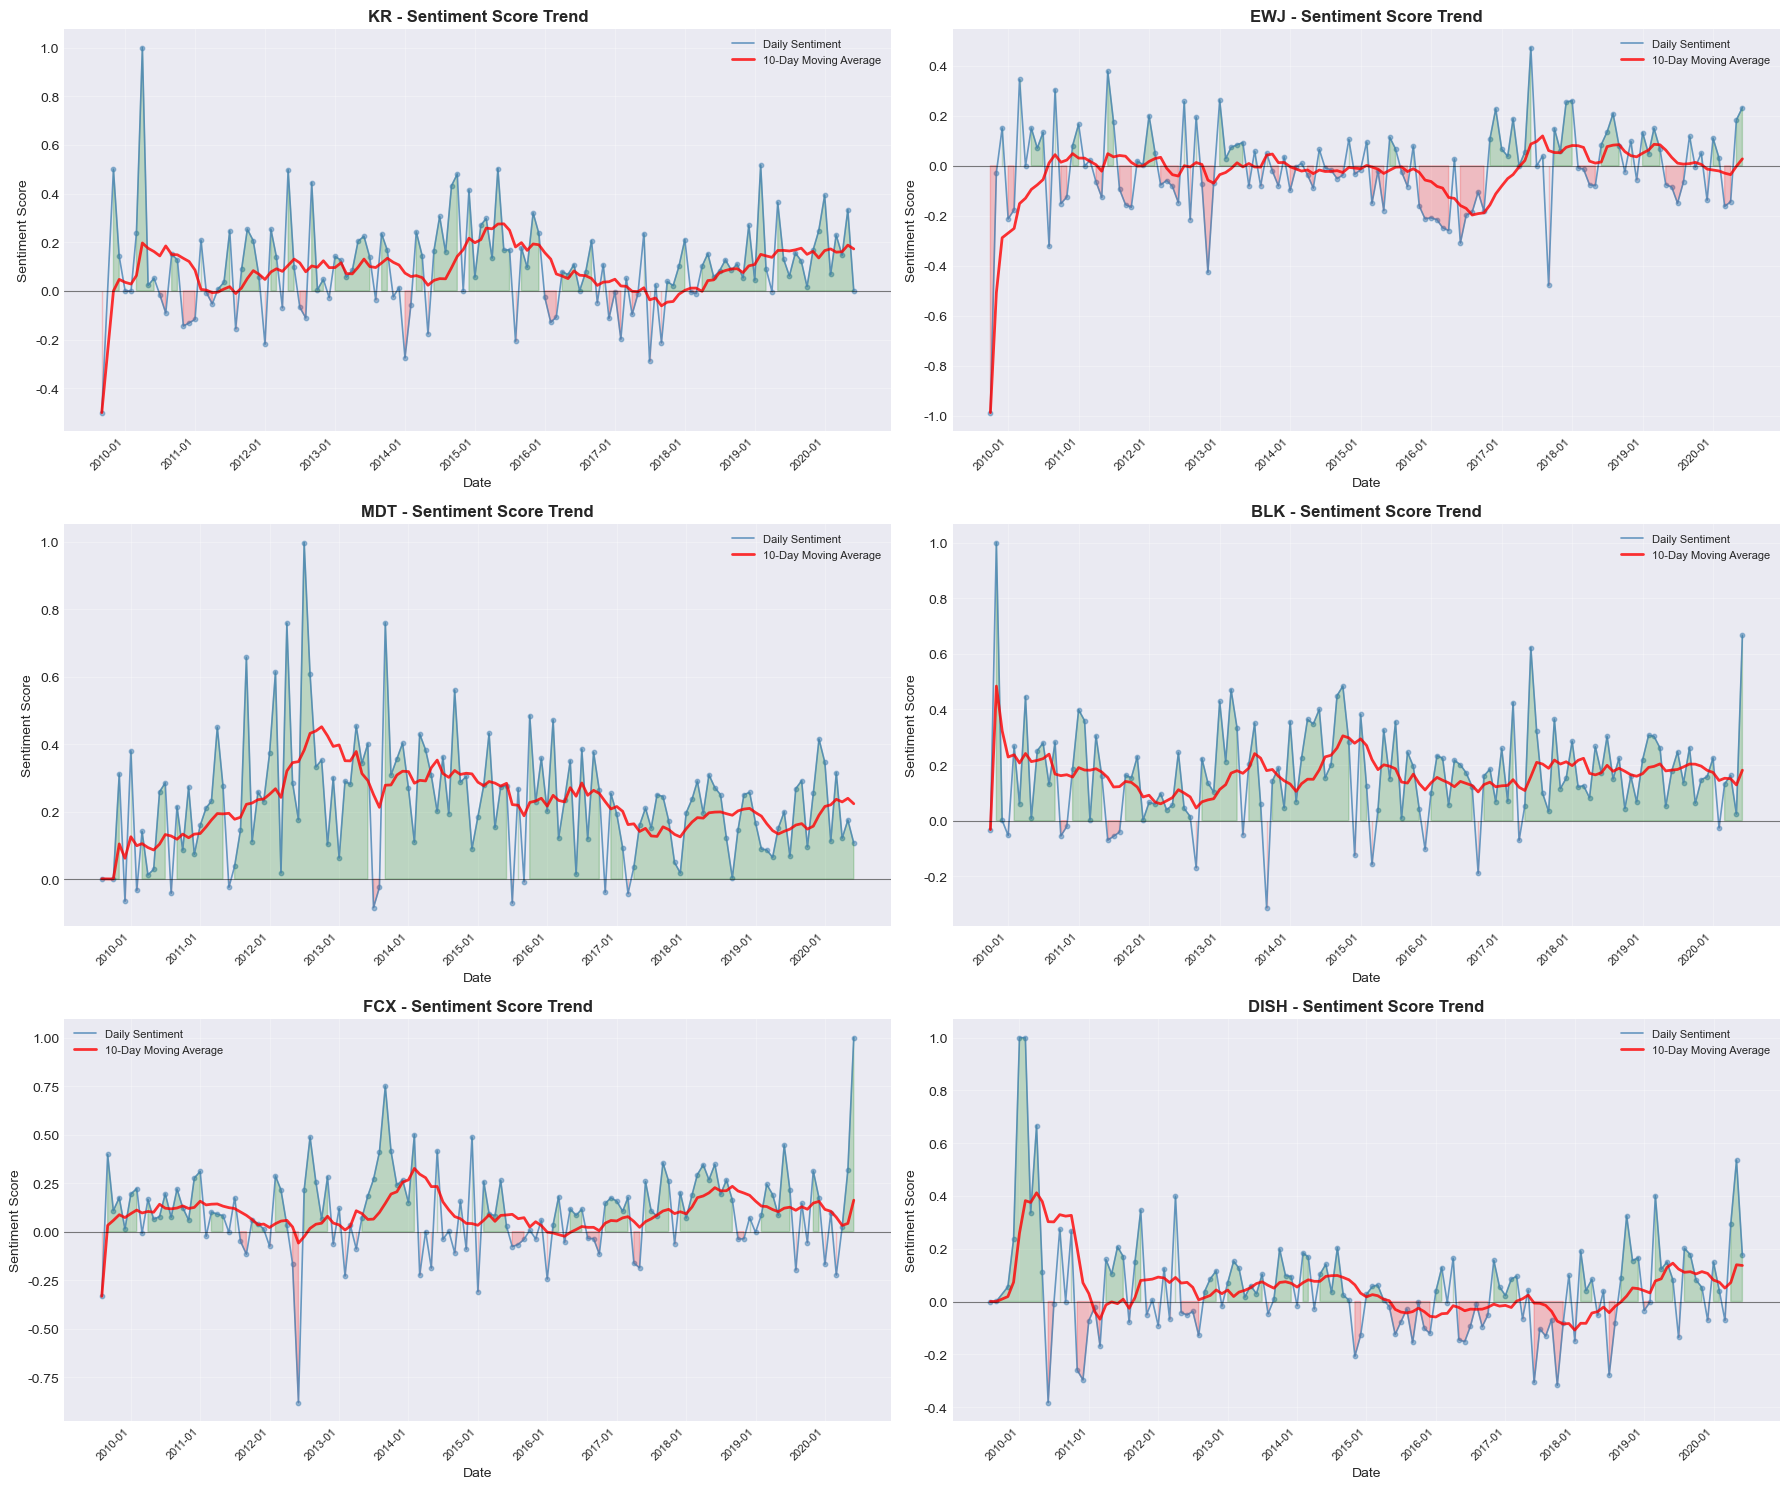

✅ Top 6 stocks sentiment trend chart completed!


In [12]:
# ============================================
# 5. Top 股票情绪时间序列（优化版）
# ============================================
import matplotlib.dates as mdates

print("="*50)
print("Plotting sentiment trends for Top 6 stocks...")
print("="*50)

# 选择前6只最常出现新闻的股票
top6_stocks = stock_frequency_sorted.head(6).index.tolist()
print(f"Top 6 stocks: {top6_stocks}")

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes_flat = axes.flatten()

for idx, stock in enumerate(top6_stocks):
    print(f"  Plotting {stock}...")
    ax = axes_flat[idx]
    
    # 筛选股票数据
    stock_data = filtered_stock_sentiment[filtered_stock_sentiment['Stock_symbol'] == stock].copy()
    
    # 确保日期格式正确（一次性转换）
    if not pd.api.types.is_datetime64_any_dtype(stock_data['Date']):
        stock_data['Date'] = pd.to_datetime(
            stock_data['Date'].astype(str).str[:10],
            format='%Y-%m-%d',
            errors='coerce'
        )
    
    # 删除无效日期并按日期排序
    stock_data = stock_data.dropna(subset=['Date']).sort_values('Date')
    
    # 如果数据量太大，进行采样（可选）
    if len(stock_data) > 500:
        print(f"    {stock} has large data volume ({len(stock_data)} rows), sampling...")
        # 按月采样
        stock_data['YearMonth'] = stock_data['Date'].dt.to_period('M')
        stock_data = (stock_data
                      .groupby('YearMonth', as_index=False)
                      .agg({'avg_sentiment_score': 'mean'})
                      .rename(columns={'YearMonth': 'Date'}))
        stock_data['Date'] = stock_data['Date'].dt.to_timestamp()
        print(f"    After sampling: {len(stock_data)} rows")
    
    # 绘制主线条
    ax.plot(stock_data['Date'], stock_data['avg_sentiment_score'], 
            linewidth=1.2, color='steelblue', alpha=0.8, label='Daily Sentiment')
    
    # 可选：添加散点（只在数据量小时使用）
    if len(stock_data) <= 200:
        ax.scatter(stock_data['Date'], stock_data['avg_sentiment_score'], 
                   s=10, alpha=0.5, color='steelblue')
    
    # 添加移动平均
    if len(stock_data) > 5:
        window = min(10, max(3, len(stock_data) // 10))  # 动态窗口大小
        ma = stock_data['avg_sentiment_score'].rolling(window=window, min_periods=1).mean()
        ax.plot(stock_data['Date'], ma, linewidth=2, color='red', 
                label=f'{window}-Day Moving Average', alpha=0.8)
    
    # 添加零线
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    
    # 填充正负区域（简化，提高速度）
    positive_mask = stock_data['avg_sentiment_score'] > 0
    negative_mask = stock_data['avg_sentiment_score'] < 0
    
    if positive_mask.any():
        ax.fill_between(stock_data['Date'], 0, stock_data['avg_sentiment_score'],
                        where=positive_mask, color='green', alpha=0.2)
    if negative_mask.any():
        ax.fill_between(stock_data['Date'], 0, stock_data['avg_sentiment_score'],
                        where=negative_mask, color='red', alpha=0.2)
    
    # 设置标题和标签
    ax.set_title(f'{stock} - Sentiment Score Trend', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Sentiment Score', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    
    # 优化x轴刻度
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    # 根据数据范围设置刻度间隔
    years_range = (stock_data['Date'].max() - stock_data['Date'].min()).days / 365.25
    if years_range > 5:
        ax.xaxis.set_major_locator(mdates.YearLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

# 隐藏多余的子图（如果不足6只股票）
for idx in range(len(top6_stocks), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()

# 保存图片
import os
os.makedirs(output_necessary_figures_dir, exist_ok=True)
save_path = f'{output_necessary_figures_dir}/05_top_stocks_sentiment_trend.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')  # 降低dpi从300到200
print(f"\n✅ Image saved: {save_path}")

plt.show()
print("✅ Top 6 stocks sentiment trend chart completed!")

In [11]:
# ============================================
# 5. Top 股票情绪时间序列（单独大图版）
# ============================================
import matplotlib.dates as mdates

print("="*50)
print("Plotting large charts for each stock individually...")
print("="*50)

# 选择前6只最常出现新闻的股票
top6_stocks = stock_frequency_sorted.head(6).index.tolist()

# 为每只股票单独创建图形
for stock in top6_stocks:
    print(f"Plotting {stock}...")
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # 筛选股票数据
    stock_data = filtered_stock_sentiment[filtered_stock_sentiment['Stock_symbol'] == stock].copy()
    
    # 确保日期格式正确
    if not pd.api.types.is_datetime64_any_dtype(stock_data['Date']):
        stock_data['Date'] = pd.to_datetime(
            stock_data['Date'].astype(str).str[:10],
            format='%Y-%m-%d',
            errors='coerce'
        )
    
    stock_data = stock_data.dropna(subset=['Date']).sort_values('Date')
    
    # 计算统计数据
    avg_score = stock_data['avg_sentiment_score'].mean()
    news_count = len(stock_data)
    positive_pct = (stock_data['avg_sentiment_score'] > 0).sum() / news_count * 100
    negative_pct = (stock_data['avg_sentiment_score'] < 0).sum() / news_count * 100
    
    # 绘制
    ax.plot(stock_data['Date'], stock_data['avg_sentiment_score'], 
            linewidth=1.5, color='steelblue', alpha=0.7, label='Daily Sentiment')
    
    # 移动平均
    if len(stock_data) > 5:
        window = min(20, len(stock_data) // 5)
        ma = stock_data['avg_sentiment_score'].rolling(window=window, min_periods=1).mean()
        ax.plot(stock_data['Date'], ma, linewidth=2.5, color='red', 
                label=f'{window}-Day Moving Average')
    
    # 零线
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # 填充
    ax.fill_between(stock_data['Date'], 0, stock_data['avg_sentiment_score'],
                    where=(stock_data['avg_sentiment_score'] > 0), 
                    color='green', alpha=0.2, label='Positive Sentiment')
    ax.fill_between(stock_data['Date'], 0, stock_data['avg_sentiment_score'],
                    where=(stock_data['avg_sentiment_score'] < 0), 
                    color='red', alpha=0.2, label='Negative Sentiment')
    
    # 标题和标签
    ax.set_title(f'{stock} - Sentiment Score Trend Analysis\n'
                 f'Average Score: {avg_score:.3f} | Total News: {news_count:,} | '
                 f'Positive Percentage: {positive_pct:.1f}% | Negative Percentage: {negative_pct:.1f}%',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Sentiment Score', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=10)
    
    # 优化x轴
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    date_span = (stock_data['Date'].max() - stock_data['Date'].min()).days
    if date_span > 1000:
        ax.xaxis.set_major_locator(mdates.YearLocator())
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    
    # 保存
    save_path = f'{output_necessary_figures_dir}/05_{stock}_sentiment_trend.png'
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()  # 关闭图形，释放内存
    print(f"  ✅ Saved: {save_path}")

print(f"\n✅ All stock charts completed! Total {len(top6_stocks)} charts")

Plotting large charts for each stock individually...
Plotting KR...
  ✅ Saved: finbert_output/2019to2020/figures/05_KR_sentiment_trend.png
Plotting EWJ...
  ✅ Saved: finbert_output/2019to2020/figures/05_EWJ_sentiment_trend.png
Plotting MDT...
  ✅ Saved: finbert_output/2019to2020/figures/05_MDT_sentiment_trend.png
Plotting BLK...
  ✅ Saved: finbert_output/2019to2020/figures/05_BLK_sentiment_trend.png
Plotting FCX...
  ✅ Saved: finbert_output/2019to2020/figures/05_FCX_sentiment_trend.png
Plotting DISH...
  ✅ Saved: finbert_output/2019to2020/figures/05_DISH_sentiment_trend.png

✅ All stock charts completed! Total 6 charts


#### 6. 情绪分布热力图 (股票 vs 星期)

绘制股票-星期情感热力图...
处理日期格式...
数据量: 1,913,379 行
选择新闻最多的 30 只股票...
选中的股票: ['KR', 'EWJ', 'MDT', 'BLK', 'FCX']... (共30只)
计算股票-星期平均情感分数...
有效股票数: 30
图形尺寸: 12 x 9.0 英寸
绘制热力图...

统计信息:
  最高平均情感: 0.262
  最低平均情感: -0.246
  整体平均情感: 0.092

✅ 图片已保存: finbert_output/2019to2020/figures/06_stock_weekday_sentiment_heatmap.png
   文件大小: 0.51 MB


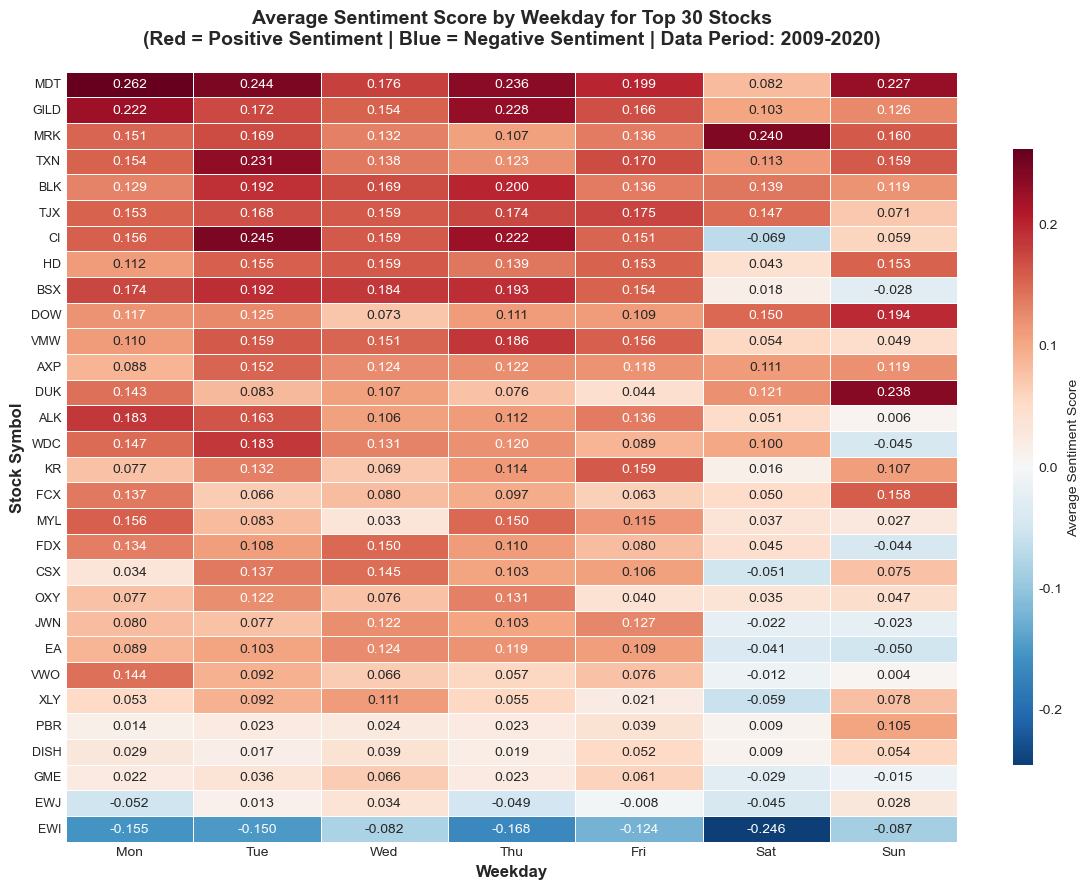

✅ 热力图绘制完成！


In [17]:
# ============================================
# 6. 情绪分布热力图 (股票 vs 星期) - 优化版
# ============================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("="*50)
print("绘制股票-星期情感热力图...")
print("="*50)

# 确保日期格式正确
print("处理日期格式...")
if not pd.api.types.is_datetime64_any_dtype(filtered_stock_sentiment['Date']):
    filtered_stock_sentiment['Date'] = pd.to_datetime(
        filtered_stock_sentiment['Date'].astype(str).str[:10],
        format='%Y-%m-%d',
        errors='coerce'
    )

# 添加星期几信息
filtered_stock_sentiment['Weekday'] = filtered_stock_sentiment['Date'].dt.day_name()
filtered_stock_sentiment['Weekday_Num'] = filtered_stock_sentiment['Date'].dt.dayofweek

print(f"数据量: {len(filtered_stock_sentiment):,} 行")

# 选择新闻最多的股票（可调整数量）
n_stocks = 30  # 可以改为 20, 30, 40 等
print(f"选择新闻最多的 {n_stocks} 只股票...")

top_stocks = stock_frequency_sorted.head(n_stocks).index.tolist()
print(f"选中的股票: {top_stocks[:5]}... (共{len(top_stocks)}只)")

# 创建股票-星期平均情感矩阵
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("计算股票-星期平均情感分数...")
stock_weekday_sentiment = (
    filtered_stock_sentiment[filtered_stock_sentiment['Stock_symbol'].isin(top_stocks)]
    .groupby(['Stock_symbol', 'Weekday'])['avg_sentiment_score']
    .mean()
    .unstack()
)

# 重新排序星期
stock_weekday_sentiment = stock_weekday_sentiment.reindex(columns=weekday_order)

# 删除全为NaN的行
stock_weekday_sentiment = stock_weekday_sentiment.dropna(axis=0, how='all')
print(f"有效股票数: {len(stock_weekday_sentiment)}")

# 按平均情感分数排序（可选：按正面情绪排序）
stock_weekday_sentiment['avg_overall'] = stock_weekday_sentiment.mean(axis=1)
stock_weekday_sentiment = stock_weekday_sentiment.sort_values('avg_overall', ascending=False)
stock_weekday_sentiment = stock_weekday_sentiment.drop('avg_overall', axis=1)

# 设置图形大小（根据股票数量动态调整）
fig_height = max(8, len(stock_weekday_sentiment) * 0.3)  # 每个股票0.3英寸
fig, ax = plt.subplots(figsize=(12, fig_height))
print(f"图形尺寸: 12 x {fig_height:.1f} 英寸")

# 绘制热力图
print("绘制热力图...")
heatmap = sns.heatmap(
    stock_weekday_sentiment, 
    annot=True,  # 显示数值
    fmt='.3f',   # 保留3位小数
    cmap='RdBu_r',  # 红蓝渐变（红色=正面，蓝色=负面）
    center=0,       # 中心为0
    square=False,   # 不强制方形（因为股票数量多）
    linewidths=0.5,  # 网格线宽度
    ax=ax,
    cbar_kws={
        'label': 'Average Sentiment Score',
        'shrink': 0.8,  # 颜色条大小
        'aspect': 30
    }
)

# 设置标题和标签
ax.set_title(
    f'Average Sentiment Score by Weekday for Top {len(stock_weekday_sentiment)} Stocks\n'
    f'(Red = Positive Sentiment | Blue = Negative Sentiment | Data Period: 2009-2020)',
    fontsize=14, 
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Weekday', fontsize=12, fontweight='bold')
ax.set_ylabel('Stock Symbol', fontsize=12, fontweight='bold')

# 优化x轴标签（星期缩写，避免重叠）
weekday_abbr = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax.set_xticklabels(weekday_abbr, rotation=0, fontsize=10)

# 优化y轴标签（股票代码）
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

# 添加网格线
ax.grid(False)  # 热力图不需要网格

# 添加数值统计信息
print("\n统计信息:")
print(f"  最高平均情感: {stock_weekday_sentiment.max().max():.3f}")
print(f"  最低平均情感: {stock_weekday_sentiment.min().min():.3f}")
print(f"  整体平均情感: {stock_weekday_sentiment.mean().mean():.3f}")

plt.tight_layout()

# 保存图片
import os
os.makedirs(output_necessary_figures_dir, exist_ok=True)
save_path = f'{output_necessary_figures_dir}/06_stock_weekday_sentiment_heatmap.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f"\n✅ 图片已保存: {save_path}")
print(f"   文件大小: {os.path.getsize(save_path) / (1024**2):.2f} MB")

plt.show()
print("✅ 热力图绘制完成！")

绘制股票-星期情感热力图（增强版）...
选择新闻最多的 30 只股票...
有效股票数: 30
绘制情感分数热力图...
绘制样本数量热力图...

✅ 增强版图片已保存: finbert_output/2019to2020/figures/06_stock_weekday_sentiment_heatmap_enhanced.png


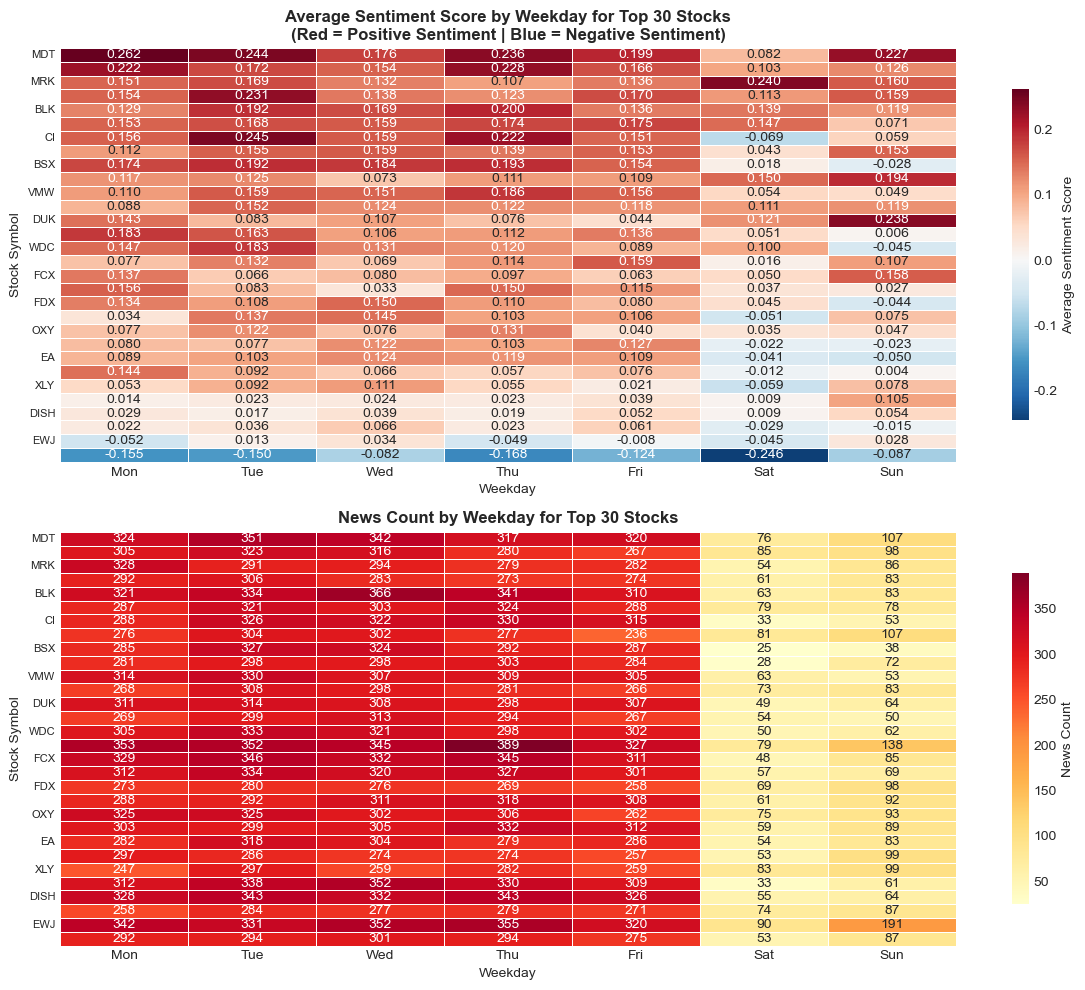

✅ 热力图绘制完成！


In [15]:
# ============================================
# 6. 情绪分布热力图 (股票 vs 星期) - 增强版
# ============================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("="*50)
print("绘制股票-星期情感热力图（增强版）...")
print("="*50)

# 准备数据
if not pd.api.types.is_datetime64_any_dtype(filtered_stock_sentiment['Date']):
    filtered_stock_sentiment['Date'] = pd.to_datetime(
        filtered_stock_sentiment['Date'].astype(str).str[:10],
        format='%Y-%m-%d',
        errors='coerce'
    )

filtered_stock_sentiment['Weekday'] = filtered_stock_sentiment['Date'].dt.day_name()
filtered_stock_sentiment['Weekday_Num'] = filtered_stock_sentiment['Date'].dt.dayofweek

# 可以选择不同数量的股票
n_stocks = 30
print(f"选择新闻最多的 {n_stocks} 只股票...")

top_stocks = stock_frequency_sorted.head(n_stocks).index.tolist()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 创建矩阵
stock_weekday_sentiment = (
    filtered_stock_sentiment[filtered_stock_sentiment['Stock_symbol'].isin(top_stocks)]
    .groupby(['Stock_symbol', 'Weekday'])['avg_sentiment_score']
    .agg(['mean', 'count', 'std'])  # 同时计算均值、计数和标准差
    .reset_index()
)

# 分别创建均值和计数矩阵
mean_matrix = stock_weekday_sentiment.pivot(index='Stock_symbol', columns='Weekday', values='mean')
count_matrix = stock_weekday_sentiment.pivot(index='Stock_symbol', columns='Weekday', values='count')

# 重新排序
mean_matrix = mean_matrix.reindex(columns=weekday_order)
count_matrix = count_matrix.reindex(columns=weekday_order)

# 按整体均值排序
mean_matrix['avg_overall'] = mean_matrix.mean(axis=1)
mean_matrix = mean_matrix.sort_values('avg_overall', ascending=False)
mean_matrix = mean_matrix.drop('avg_overall', axis=1)

# 同步排序计数矩阵
count_matrix = count_matrix.loc[mean_matrix.index]

# 删除全为NaN的行
mean_matrix = mean_matrix.dropna(axis=0, how='all')
count_matrix = count_matrix.loc[mean_matrix.index]

print(f"有效股票数: {len(mean_matrix)}")

# 创建图形（使用子图，同时显示均值和样本量）
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, max(10, len(mean_matrix) * 0.25)))

# 图1：情感分数热力图
print("绘制情感分数热力图...")
heatmap1 = sns.heatmap(
    mean_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    ax=ax1,
    cbar_kws={'label': 'Average Sentiment Score', 'shrink': 0.8}
)

ax1.set_title(
    f'Average Sentiment Score by Weekday for Top {len(mean_matrix)} Stocks\n'
    f'(Red = Positive Sentiment | Blue = Negative Sentiment)',
    fontsize=12,
    fontweight='bold'
)
ax1.set_xlabel('Weekday', fontsize=10)
ax1.set_ylabel('Stock Symbol', fontsize=10)
ax1.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)

# 图2：样本数量热力图
print("绘制样本数量热力图...")
heatmap2 = sns.heatmap(
    count_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax2,
    cbar_kws={'label': 'News Count', 'shrink': 0.8}
)

ax2.set_title(
    f'News Count by Weekday for Top {len(count_matrix)} Stocks',
    fontsize=12,
    fontweight='bold'
)
ax2.set_xlabel('Weekday', fontsize=10)
ax2.set_ylabel('Stock Symbol', fontsize=10)
ax2.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)

# 调整y轴标签字体
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=8)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=8)

plt.tight_layout()

# 保存图片
save_path = f'{output_necessary_figures_dir}/06_stock_weekday_sentiment_heatmap_enhanced.png'
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f"\n✅ 增强版图片已保存: {save_path}")

plt.show()
print("✅ 热力图绘制完成！")

In [16]:
# 在热力图后添加分析代码
print("\n" + "="*60)
print("热力图分析报告")
print("="*60)

# 1. 找出最佳组合
print("\n🌟 最佳组合（高情感 + 高数量）:")
for stock in mean_matrix.index:
    for day in mean_matrix.columns:
        sentiment = mean_matrix.loc[stock, day]
        count = count_matrix.loc[stock, day] if 'count_matrix' in locals() else 0
        
        if sentiment > 0.1 and count > count_matrix.mean().mean():
            print(f"  {stock} 在 {day}: 情感={sentiment:.3f}, 新闻={int(count)}条")

# 2. 识别星期规律
print("\n📅 各星期平均情绪:")
weekday_avg = mean_matrix.mean(axis=0)
for day, score in weekday_avg.items():
    print(f"  {day}: {score:.3f}")

# 3. 识别最佳/最差股票
print(f"\n🏆 整体情绪最好的股票: {mean_matrix.mean(axis=1).idxmax()} "
      f"({mean_matrix.mean(axis=1).max():.3f})")
print(f"📉 整体情绪最差的股票: {mean_matrix.mean(axis=1).idxmin()} "
      f"({mean_matrix.mean(axis=1).min():.3f})")

# 4. 识别周末效应
weekend_avg = mean_matrix[['Saturday', 'Sunday']].mean().mean()
weekday_avg = mean_matrix[['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']].mean().mean()
print(f"\n周末平均情绪: {weekend_avg:.3f}")
print(f"工作日平均情绪: {weekday_avg:.3f}")
if weekend_avg < weekday_avg:
    print("💡 周末新闻情绪普遍较差")
else:
    print("💡 周末新闻情绪普遍较好")


热力图分析报告

🌟 最佳组合（高情感 + 高数量）:
  MDT 在 Monday: 情感=0.262, 新闻=324条
  MDT 在 Tuesday: 情感=0.244, 新闻=351条
  MDT 在 Wednesday: 情感=0.176, 新闻=342条
  MDT 在 Thursday: 情感=0.236, 新闻=317条
  MDT 在 Friday: 情感=0.199, 新闻=320条
  GILD 在 Monday: 情感=0.222, 新闻=305条
  GILD 在 Tuesday: 情感=0.172, 新闻=323条
  GILD 在 Wednesday: 情感=0.154, 新闻=316条
  GILD 在 Thursday: 情感=0.228, 新闻=280条
  GILD 在 Friday: 情感=0.166, 新闻=267条
  MRK 在 Monday: 情感=0.151, 新闻=328条
  MRK 在 Tuesday: 情感=0.169, 新闻=291条
  MRK 在 Wednesday: 情感=0.132, 新闻=294条
  MRK 在 Thursday: 情感=0.107, 新闻=279条
  MRK 在 Friday: 情感=0.136, 新闻=282条
  TXN 在 Monday: 情感=0.154, 新闻=292条
  TXN 在 Tuesday: 情感=0.231, 新闻=306条
  TXN 在 Wednesday: 情感=0.138, 新闻=283条
  TXN 在 Thursday: 情感=0.123, 新闻=273条
  TXN 在 Friday: 情感=0.170, 新闻=274条
  BLK 在 Monday: 情感=0.129, 新闻=321条
  BLK 在 Tuesday: 情感=0.192, 新闻=334条
  BLK 在 Wednesday: 情感=0.169, 新闻=366条
  BLK 在 Thursday: 情感=0.200, 新闻=341条
  BLK 在 Friday: 情感=0.136, 新闻=310条
  TJX 在 Monday: 情感=0.153, 新闻=287条
  TJX 在 Tuesday: 情感=0.168, 新闻=321条
  TJX 在 Wednesday


##### 总结：如何用好这两个图

📌 优化版（基础版）
- **用途**：快速了解整体分布
- **看什么**：颜色深浅分布，识别明显模式
- **适合**：初步分析、演示汇报

📌 增强版（双图版）
- **用途**：深度分析，避免小样本误导
- **看什么**：
  - 上图的**情感方向**
  - 下图的**可信度**（新闻量）
- **适合**：投资决策、研究报告

🎯 关键洞察点
1. **高情感 + 高数量** = 强信号（值得关注）
2. **高情感 + 低数量** = 谨慎（可能只是偶然）
3. **低情感 + 高数量** = 风险信号（需要警惕）
4. **颜色模式** = 识别规律（某天总是红/蓝）

#### 7. 统计摘要表格

In [ ]:

# ============================================
# 7. 统计摘要表格
# ============================================
print("\n" + "="*60)
print("统计摘要")
print("="*60)

print(f"\n📊 数据概览:")
print(f"  - 分析时间段: {filtered_stock_sentiment['Date'].min().date()} 到 {filtered_stock_sentiment['Date'].max().date()}")
print(f"  - 总天数: {total_days} 天")
print(f"  - 总股票数量: {len(stock_frequency)} 只")
print(f"  - 总股票-日期组合: {len(filtered_stock_sentiment)} 条")

print(f"\n📈 新闻覆盖统计:")
print(f"  - 平均每天有新闻的股票: {daily_stock_count['stock_count'].mean():.2f} 只")
print(f"  - 中位数每天有新闻的股票: {daily_stock_count['stock_count'].median():.0f} 只")
print(f"  - 股票平均覆盖天数: {stock_frequency['days_with_news'].mean():.2f} 天")
print(f"  - 股票平均覆盖率: {stock_frequency['coverage_rate'].mean():.2f}%")

print(f"\n🎭 情绪统计:")
print(f"  - 整体平均情感分数: {filtered_stock_sentiment['avg_sentiment_score'].mean():.4f}")
print(f"  - 情绪标准差: {filtered_stock_sentiment['avg_sentiment_score'].std():.4f}")
print(f"  - 最正面情绪: {filtered_stock_sentiment['avg_sentiment_score'].max():.4f}")
print(f"  - 最负面情绪: {filtered_stock_sentiment['avg_sentiment_score'].min():.4f}")

print(f"\n📅 星期模式:")
for _, row in weekday_stats_sorted.iterrows():
    print(f"  - {row['Weekday']}: {row['news_count']:,} 条新闻, {row['Stock_symbol']} 只股票")

print(f"\n🏆 Top 5 高频股票:")
# for stock in top5_stocks:
#     data = stock_frequency.loc[stock]
#     print(f"  - {stock}: {data['days_with_news']} 天 ({data['coverage_rate']:.1f}%), {data['total_news']} 条新闻")

print(f"\n✅ 所有图表已保存到: {output_necessary_figures_dir}")

#### 可视化分析报告：


In [25]:
# ============================================
# 自动分析报告：解读图表关键发现
# ============================================

def generate_analysis_report():
    """生成图表分析报告"""
    
    print("\n" + "="*70)
    print("📈 股票新闻覆盖与情感分析报告")
    print("="*70)
    
    # ============================================
    # 图1分析：股票新闻覆盖
    # ============================================
    print("\n【图1：股票新闻覆盖频率分布】")
    print("-" * 50)
    
    # 基本统计
    total_stocks = len(stock_frequency)
    avg_days = stock_frequency['days_with_news'].mean()
    median_days = stock_frequency['days_with_news'].median()
    max_days = stock_frequency['days_with_news'].max()
    min_days = stock_frequency['days_with_news'].min()
    
    print(f"📊 基本统计:")
    print(f"   • 总股票数: {total_stocks:,} 只")
    print(f"   • 平均新闻覆盖天数: {avg_days:.1f} 天")
    print(f"   • 中位数覆盖天数: {median_days:.0f} 天")
    print(f"   • 最大覆盖天数: {max_days:.0f} 天")
    print(f"   • 最小覆盖天数: {min_days:.0f} 天")
    
    # 分布特征
    q75 = stock_frequency['days_with_news'].quantile(0.75)
    q25 = stock_frequency['days_with_news'].quantile(0.25)
    print(f"\n📈 分布特征:")
    print(f"   • 上四分位数 (75%): {q75:.0f} 天")
    print(f"   • 下四分位数 (25%): {q25:.0f} 天")
    print(f"   • 四分位距: {q75 - q25:.0f} 天")
    
    # 覆盖天数最多和最少的股票
    top_coverage = stock_frequency_sorted.head(3)
    bottom_coverage = stock_frequency_sorted.tail(3)
    print(f"\n🏆 新闻覆盖天数最多的股票:")
    for stock, row in top_coverage.iterrows():
        print(f"   • {stock}: {row['days_with_news']:.0f} 天, {row['total_news']:,} 条新闻")
    print(f"\n📉 新闻覆盖天数最少的股票:")
    for stock, row in bottom_coverage.iterrows():
        print(f"   • {stock}: {row['days_with_news']:.0f} 天, {row['total_news']:,} 条新闻")
    
    # 覆盖率分析
    avg_rate = stock_frequency['coverage_rate'].mean()
    high_coverage = (stock_frequency['coverage_rate'] > 50).sum()
    print(f"\n📊 覆盖率分析:")
    print(f"   • 平均覆盖率: {avg_rate:.1f}%")
    print(f"   • 高覆盖率股票 (>50%): {high_coverage} 只 ({high_coverage/total_stocks*100:.1f}%)")
    
    # ============================================
    # 图2分析：每周模式
    # ============================================
    print("\n【图2：每周新闻模式分析】")
    print("-" * 50)
    
    # 找到新闻最多和最少的星期
    max_news_day = weekday_stats_sorted.loc[weekday_stats_sorted['news_count'].idxmax()]
    min_news_day = weekday_stats_sorted.loc[weekday_stats_sorted['news_count'].idxmin()]
    avg_news = weekday_stats_sorted['news_count'].mean()
    
    print(f"📅 新闻发布规律:")
    print(f"   • 新闻最多的一天: {max_news_day['Weekday']} ({max_news_day['news_count']/1000:.1f}k 条)")
    print(f"   • 新闻最少的一天: {min_news_day['Weekday']} ({min_news_day['news_count']/1000:.1f}k 条)")
    print(f"   • 周平均新闻量: {avg_news/1000:.1f}k 条")
    
    # 工作日 vs 周末
    weekday_news = weekday_stats_sorted[weekday_stats_sorted['Weekday'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]['news_count'].mean()
    weekend_news = weekday_stats_sorted[weekday_stats_sorted['Weekday'].isin(['Saturday', 'Sunday'])]['news_count'].mean()
    print(f"\n📆 工作日 vs 周末:")
    print(f"   • 工作日平均: {weekday_news/1000:.1f}k 条")
    print(f"   • 周末平均: {weekend_news/1000:.1f}k 条")
    print(f"   • 差异: {(weekday_news - weekend_news)/1000:.1f}k 条 ({((weekday_news-weekend_news)/weekend_news*100):.0f}% 更多)")
    
    # 股票数量分析
    max_stocks_day = weekday_stats_sorted.loc[weekday_stats_sorted['Stock_symbol'].idxmax()]
    print(f"\n🏢 股票活跃度:")
    print(f"   • 最活跃的一天: {max_stocks_day['Weekday']} ({max_stocks_day['Stock_symbol']:.0f} 只股票)")
    
    # ============================================
    # 图3分析：股票情绪
    # ============================================
    print("\n【图3：股票情绪分析】")
    print("-" * 50)
    
    # 情绪分布
    sentiment_scores = filtered_stock_sentiment['avg_sentiment_score']
    pos_pct = (sentiment_scores > 0).sum() / len(sentiment_scores) * 100
    neg_pct = (sentiment_scores < 0).sum() / len(sentiment_scores) * 100
    neu_pct = (sentiment_scores == 0).sum() / len(sentiment_scores) * 100
    
    print(f"😊 情绪分布:")
    print(f"   • 正面情绪: {pos_pct:.1f}%")
    print(f"   • 负面情绪: {neg_pct:.1f}%")
    print(f"   • 中性情绪: {neu_pct:.1f}%")
    print(f"   • 平均情感分数: {sentiment_scores.mean():.4f}")
    print(f"   • 情感分数中位数: {sentiment_scores.median():.4f}")
    
    # 最正面和最负面的股票
    most_positive = stock_volatility.nlargest(1, 'avg_sentiment_mean')
    most_negative = stock_volatility.nsmallest(1, 'avg_sentiment_mean')
    print(f"\n🎯 极端情绪股票:")
    print(f"   • 最正面股票: {most_positive.index[0]} (平均分: {most_positive['avg_sentiment_mean'].iloc[0]:.4f})")
    print(f"   • 最负面股票: {most_negative.index[0]} (平均分: {most_negative['avg_sentiment_mean'].iloc[0]:.4f})")
    
    # 波动性分析
    avg_volatility = stock_volatility['sentiment_volatility'].mean()
    high_volatility = stock_volatility[stock_volatility['sentiment_volatility'] > avg_volatility].shape[0]
    most_volatile = stock_volatility.nlargest(1, 'sentiment_volatility')
    least_volatile = stock_volatility.nsmallest(1, 'sentiment_volatility')
    
    print(f"\n🌊 情绪波动性:")
    print(f"   • 平均波动性: {avg_volatility:.4f}")
    print(f"   • 高波动股票数: {high_volatility} 只 ({high_volatility/len(stock_volatility)*100:.1f}%)")
    print(f"   • 波动最大股票: {most_volatile.index[0]} (标准差: {most_volatile['sentiment_volatility'].iloc[0]:.4f})")
    print(f"   • 波动最小股票: {least_volatile.index[0]} (标准差: {least_volatile['sentiment_volatility'].iloc[0]:.4f})")
    
    # 相关关系
    correlation = stock_volatility['avg_sentiment_mean'].corr(stock_volatility['sentiment_volatility'])
    print(f"\n📊 相关性分析:")
    if correlation > 0.5:
        print(f"   • 平均情绪与波动性呈正相关 ({correlation:.3f})")
        print(f"     → 情绪越正面的股票，波动性越大")
    elif correlation < -0.5:
        print(f"   • 平均情绪与波动性呈负相关 ({correlation:.3f})")
        print(f"     → 情绪越负面的股票，波动性越大")
    else:
        print(f"   • 平均情绪与波动性无明显相关 ({correlation:.3f})")
    
    # ============================================
    # 综合洞察
    # ============================================
    print("\n【💡 核心洞察与建议】")
    print("-" * 50)
    
    insights = []
    
    # 洞察1：新闻发布规律
    if weekday_news > weekend_news * 1.5:
        insights.append("📌 新闻发布集中在工作日，周末新闻量显著减少")
    elif max_news_day['Weekday'] in ['Monday', 'Tuesday']:
        insights.append("📌 周一、周二是新闻发布高峰期，适合关注市场动态")
    
    # 洞察2：情绪分布
    if pos_pct > 60:
        insights.append("📌 市场整体情绪偏正面，大部分新闻具有积极倾向")
    elif neg_pct > 30:
        insights.append("📌 存在一定比例的负面新闻，需要关注风险")
    
    # 洞察3：波动性
    if high_volatility > len(stock_volatility) * 0.3:
        insights.append("📌 超过30%的股票情绪波动较大，市场存在分歧")
    
    # 洞察4：极端股票
    if len(top_positive) > 0:
        insights.append(f"📌 关注积极信号: {most_positive.index[0]} 持续表现正面")
    if len(most_negative) > 0:
        insights.append(f"📌 警惕风险: {most_negative.index[0]} 情绪持续负面")
    
    for i, insight in enumerate(insights, 1):
        print(f"   {insight}")
    
    print("\n" + "="*70)
    print("分析完成！")
    print("="*70)

# 运行分析报告
generate_analysis_report()


📈 股票新闻覆盖与情感分析报告

【图1：股票新闻覆盖频率分布】
--------------------------------------------------
📊 基本统计:
   • 总股票数: 6,619 只
   • 平均新闻覆盖天数: 289.1 天
   • 中位数覆盖天数: 181 天
   • 最大覆盖天数: 1983 天
   • 最小覆盖天数: 1 天

📈 分布特征:
   • 上四分位数 (75%): 401 天
   • 下四分位数 (25%): 52 天
   • 四分位距: 349 天

🏆 新闻覆盖天数最多的股票:
   • KR: 1983 天, 5,126.0 条新闻
   • EWJ: 1981 天, 4,526.0 条新闻
   • MDT: 1837 天, 4,474.0 条新闻

📉 新闻覆盖天数最少的股票:
   • DVYA: 1 天, 1.0 条新闻
   • OSM: 1 天, 1.0 条新闻
   • OXLCP: 1 天, 1.0 条新闻

📊 覆盖率分析:
   • 平均覆盖率: 0.7%
   • 高覆盖率股票 (>50%): 0 只 (0.0%)

【图2：每周新闻模式分析】
--------------------------------------------------
📅 新闻发布规律:
   • 新闻最多的一天: Wednesday (664.8k 条)
   • 新闻最少的一天: Saturday (54.0k 条)
   • 周平均新闻量: 464.6k 条

📆 工作日 vs 周末:
   • 工作日平均: 623.4k 条
   • 周末平均: 67.7k 条
   • 差异: 555.7k 条 (820% 更多)

🏢 股票活跃度:
   • 最活跃的一天: Wednesday (6513 只股票)

【图3：股票情绪分析】
--------------------------------------------------
😊 情绪分布:
   • 正面情绪: 47.3%
   • 负面情绪: 52.7%
   • 中性情绪: 0.0%
   • 平均情感分数: 0.1089
   • 情感分数中位数: -0.0000

🎯 极端情绪股票:
   • 最正面股票: 1087 




##### 1. **股票新闻覆盖分布图** (`01_stock_coverage_distribution.png`)
- 股票覆盖天数分布直方图
- 股票覆盖率分布直方图
- Top 20 股票覆盖天数排名
- Top 20 股票新闻总数排名

##### 2. **每周新闻模式图** (`02_weekly_pattern.png`)
- 各星期新闻发布总量
- 各星期有新闻的股票数量

##### 3. **股票情绪分析图** (`03_stock_sentiment_analysis.png`)
- 情感分数分布直方图
- 情绪波动性散点图（波动 vs 平均值）
- 情绪最极端股票排名
- 情绪波动最大股票排名

##### 4. **市场情绪趋势图** (`04_market_sentiment_trend.png`)
- 每日市场情绪时间序列（含移动平均线）
- 每日有新闻的股票数量柱状图

##### 5. **Top股票情绪趋势图** (`05_top_stocks_sentiment_trend.png`)
- 前6只高频股票的情感分数时间序列
- 每只股票独立的情绪趋势图

##### 6. **股票-星期热力图** (`06_stock_weekday_sentiment_heatmap.png`)
- Top 30 股票在不同星期的平均情感分数
- 热力图展示股票情绪的时间模式

这些可视化图表全面展示了：
- 新闻覆盖的时间分布
- 股票新闻频率特征
- 情绪分布和波动特征
- 市场情绪趋势
- 个股情绪变化
- 星期模式分析

所有图表都会自动保存到 `02_A_finbert/finbert_output/figures/` 目录下。